In [13]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from IPython.display import display
from scipy.stats import beta as beta_dist, norm

In [14]:
def calculate_lead_score(data, gates, modifiers):
    def bci(successes, trials, confidence=0.05):
        if trials <= 0:
            return 0.0
        s = float(successes)
        n = float(trials)
        return beta_dist.ppf(confidence, s + 1, n - s + 1)
        
    def bci_from_rate(rate, n):
        s = round(rate * n)
        return bci(s, n)
                  
    def edp(x, k):
        return np.exp(-k * x)
    def ln_norm(count, cap):
        if cap <= 0:
            return 0.0
        return min(np.log(1 + count) / np.log(1 + cap), 1.0)
        
    def sigmoid_transform(x, x0=0.50, k=8.0):
        return 1.0 / (1.0 + np.exp(-k * (x - x0)))
        
    def gaussian_penalty(actual, ideal, sigma):
        return np.exp(-((actual - ideal) ** 2) / (2 * sigma ** 2))
        
    def hrc(values, weights, delta=0.15, max_iter=100, tol=1e-6):
        values = np.array(values, dtype=float)
        weights = np.array(weights, dtype=float)
        weights = weights / weights.sum()
        theta = np.dot(weights, values)
        for _ in range(max_iter):
            residuals = np.abs(values - theta)
            adjusted_weights = weights.copy()
            for i in range(len(values)):
                if residuals[i] > delta:
                    adjusted_weights[i] = weights[i] * (delta / residuals[i])
            if adjusted_weights.sum() == 0:
                break
            theta_new = np.dot(adjusted_weights, values) / adjusted_weights.sum()
            if abs(theta_new - theta) < tol:
                theta = theta_new
                break
            theta = theta_new
        return theta
        
    def silverman_bandwidth(history):
        history = np.asarray(history, dtype=float)
        n = len(history)
        if n < 2:
            return 1.0
        sigma = np.std(history, ddof=1)
        q75, q25 = np.percentile(history, [75, 25])
        iqr = q75 - q25
        spread = min(sigma, iqr / 1.34) if iqr > 0 else sigma
        if spread <= 0:
            return 1.0
        return 0.9 * spread * (n ** (-1 / 5))
        
    def kpn(raw_score, historical_scores):
        historical_scores = np.asarray(historical_scores, dtype=float)
        n = len(historical_scores)
        if n < 2:
            return raw_score 
        h = silverman_bandwidth(historical_scores)
        if h <= 0:
            return 0.5
        z = (raw_score - historical_scores) / h
        return float(np.mean(norm.cdf(z)))
        
    def ewma_mean(values, lam=0.85):
        values = np.asarray(values, dtype=float)
        T = len(values)
        weights = np.array([lam ** (T - t - 1) for t in range(T)])
        weights /= weights.sum()
        return float(np.sum(weights * values))
    
    p1 = data[0]

    if p1["d"]==0:
        p1["d"]=1
    
    br_raw = min(p1["b"] / p1["d"], 1.0)
    Br = sigmoid_transform(br_raw, x0=0.70, k=10.0)
    
    C_stated = p1["c"]
    C_evidence = bci(p1["nconfirmedbudget"], p1["nsimilardeals"])
    C = 0.5 * C_stated + 0.5 * C_evidence
    
    F1 = edp(p1["t"], 0.25)
    
    F2 = p1["f2"]
    
    M_val = p1["m"]
    
    P_val = p1["p"]
    
    X1 = hrc(
        values=[Br, C, F1, F2, M_val, P_val],
        weights=[0.45, 0.17, 0.12, 0.12, 0.08, 0.06]
    )
    
    p2 = data[1]
    
    R_ind = p2["r"]
    S_fit = p2["s"]
    P_clar = p2["p"]
    
    T_tech = bci(p2["nfeaturesavailable"], p2["nfeaturesneeded"])
    
    F_pos = hrc(
        values=[R_ind, S_fit, P_clar, T_tech],
        weights=[0.25, 0.30, 0.20, 0.25]
    )
    
    dissatisfaction_drag = p2["d"] * p2["cs"] 
    custom_drag = p2["c"]
    
    compliance_gap = 1.0 - p2["c2"]
    compliance_penalty = edp(compliance_gap, 3.0)
    
    F_neg = hrc(
        values=[1.0 - 0.4 * dissatisfaction_drag,
                1.0 - 0.25 * custom_drag,
                compliance_penalty],
        weights=[0.40, 0.25, 0.35]
    )
    
    U_score = ln_norm(p2["u"], 6)
    
    X2 = hrc(
        values=[F_pos, F_neg, U_score],
        weights=[0.45, 0.40, 0.15]
    )
    
    p3 = data[2]
    
    A_c = p3["r"] * p3["d"]
    
    N_stake = ln_norm(p3["n"], 5)
    
    O_stated = p3["o"]
    O_evidence = bci(p3["nstakeholderssupportive"], p3["nstakeholdersmet"])
    O_combined = 0.5 * O_stated + 0.5 * O_evidence
    
    P_access = p3["p"]
    
    X3 = hrc(
        values=[A_c, N_stake, O_combined, P_access],
        weights=[0.30, 0.30, 0.25, 0.15]
    )
    
    p4 = data[3]
    
    T_prime = edp(p4["t"], 0.015)
    
    if p4["t1"] == 1:
        U_trig = edp(p4["t2"], 0.01) 
    else:
        U_trig = 0.0
    
    P_proc = 0.5 * p4["ep"] + 0.5 * p4["ns"]
    
    T_core = hrc(
        values=[T_prime, U_trig, P_proc, 1.0 - p4["cp"]], 
        weights=[0.45, 0.15, 0.25, 0.15]
    )
    
    X4 = T_core
    
    p5 = data[4]
    
    e_email_open  = ln_norm(p5["n1"], 20) 
    e_email_reply = ln_norm(p5["n2"], 10)  
    e_meetings    = ln_norm(p5["n3"], 6) 
    e_calls       = ln_norm(p5["n4"], 8)
    e_web         = ln_norm(p5["n5"], 15) 
    e_downloads   = ln_norm(p5["n6"], 8) 
    e_pricing     = ln_norm(p5["n7"], 5) 
    e_demo_req    = ln_norm(p5["n8"], 3) 
    e_social      = ln_norm(p5["n9"], 5) 
    
    
    E_composite = hrc(
        values=[e_email_open, e_email_reply, e_meetings, e_calls,
                e_web, e_downloads, e_pricing, e_demo_req, e_social],
        weights=[0.05, 0.10, 0.18, 0.12, 0.08, 0.10, 0.14, 0.18, 0.05]
    )
    
    R_decay = edp(p5["t"], 0.033)
    
    weekly = p5["weeklyengagement"]
    ewma_val = ewma_mean(weekly, lam=0.85)
    simple_mean = np.mean(weekly)
    
    V_bonus = max(0.0, (ewma_val - simple_mean) / max(simple_mean, 0.01))
    V_score = min(V_bonus, 1.0) * 0.15
    
    D_channel = ln_norm(p5["c"], 5) * 0.10
    
    N_penalty = edp(p5["m"], 0.3)
    
    E_core = hrc(
        values=[E_composite * R_decay, V_score, D_channel],
        weights=[0.75, 0.15, 0.10]
    )
    
    X5_raw = E_core * np.sqrt(N_penalty)
    X5 = sigmoid_transform(X5_raw, x0=0.3, k=8.0)
    
    
    p6 = data[5]
    
    X6_raw = hrc(
        values=[p6["seg"], p6["emp"], p6["rev"], p6["tech"],
                p6["geo"], p6["gro"], p6["f"], p6["d"], p6["l"]],
        weights=[0.20, 0.10, 0.10, 0.20, 0.05, 0.10, 0.10, 0.10, 0.05]
    )
    
    X6 = sigmoid_transform(X6_raw, x0=0.70, k=8.0)
    
    p7 = data[6]
    
    Q_stated = p7["q"]
    Q_evidence = bci(p7["nconvertedfromsource"], p7["nleadsfromsource"])
    Q = 0.5 * Q_stated + 0.5 * Q_evidence
    
    P_camp = p7["p"]
    R_data = p7["r"]
    S_dir  = p7["s"]
    
    X7 = hrc(
        values=[Q, P_camp, R_data, S_dir],
        weights=[0.55, 0.15, 0.10, 0.20]
    )
    
    
    p8 = data[7]
    
    if p8["k"] == 1:
        X8 = 1.0
    else:
        N_comp = edp(p8["n"], 0.18)
    
        W_bci = bci(p8["nwins"], p8["ncompetitivedeals"])
    
        friction = 0.5 * p8["s"] + 0.5 * p8["c"]
        Cd = edp(friction, 1.0)
    
        D_diff = p8["d"]
    
        X8 = hrc(
            values=[N_comp, W_bci, Cd, D_diff],
            weights=[0.25, 0.30, 0.20, 0.25]
        )
    
    p9 = data[8]
    
    R_ten = p9["pb"] * ln_norm(p9["rt"], 36)
    
    R_trust = hrc(
        values=[p9["es"], p9["t"], p9["rc"], max(p9["nps"], 0)],
        weights=[0.30, 0.30, 0.20, 0.20]
    )
    
    R_neg = edp(p9["n"], 1.5)
    
    X9 = R_neg * hrc(
        values=[R_ten, R_trust],
        weights=[0.40, 0.60]
    )
    
    p10 = data[9]

    if p10["cac"]==0:
        p10["cac"]=1
    
    cac_ratio = p10["ltv"] / p10["cac"]
    V_ltv = sigmoid_transform(cac_ratio, x0=3.0, k=1.5)
    
    Cs_stated = p10["cs"]
    Cs_evidence = bci(p10["nexpanded"], p10["nsimilaraccounts"])
    Cs = 0.5 * Cs_stated + 0.5 * Cs_evidence
    
    V_strat = hrc(
        values=[p10["b"], p10["m"], p10["e"]],
        weights=[0.30, 0.40, 0.30]
    )
    
    V_churn = edp(p10["c"], 1.2)
    
    X10 = V_churn * hrc(
        values=[V_ltv, Cs, V_strat],
        weights=[0.35, 0.25, 0.40]
    )
    
    g1=[]
    for i in range(len(gates)):
        h=gates[i]
        if h == 't':
            g1.append(0)
        else:
            g1.append(1)
    G=1
    for h in g1:
        G=G*h
    
    a=[]
    for i in range(len(modifiers)):
        h=modifiers[i]
        a.append(h)
    M=1
    for i in range(5):
        M=M*a[i]
    
    def mu(S, a, a_ij):
        value = sum(a[i] for i in S)
        for (i, j), coeff in a_ij.items():
            if i in S and j in S:
                value += coeff
        return value
        
    def choquet_integral(scores, a, a_ij):
        n = len(scores)
        sigma = sorted(range(n), key=lambda i: scores[i])
        integral = 0.0
        for rank in range(n):
            coalition = set(sigma[rank:])
            mu_val = mu(coalition, a, a_ij)
            if rank == 0:
                delta = scores[sigma[rank]]
            else:
                delta = scores[sigma[rank]] - scores[sigma[rank - 1]]
            integral += delta * mu_val
        return integral
        
    X_all = [X1, X2, X3, X4, X5, X6, X7, X8, X9, X10]
    
    sigmoid_indices = {3, 5, 8}  
    X_final = [
        sigmoid_transform(x, x0=0.50, k=8.0) if i in sigmoid_indices else x
        for i, x in enumerate(X_all)
    ]
    X_final = [max(0.0, min(1.0, x)) for x in X_final]
    
    a_vals = {
        0: 0.155, 1: 0.125, 2: 0.200, 3: 0.125, 4: 0.120,  
        5: 0.060, 6: 0.030, 7: 0.055, 8: 0.055, 9: 0.075,   
    }
    
    a_ij_vals = {
        (0, 3): +0.025,
        (0, 2): +0.020, 
        (1, 4): +0.015,  
        (2, 3): +0.015,  
        (7, 0): +0.015, 
        (8, 9): +0.010, 
        (4, 8): -0.010,  
        (5, 6): -0.010,   
        (1, 5): -0.005,   
    }
    
    C_mu = choquet_integral(X_final, a_vals, a_ij_vals)
    mu_N = mu(set(range(10)), a_vals, a_ij_vals)
    
    S = 100.0 * G * M * (C_mu / mu_N)
        
    return {
        "score":       S,
        "gate_result": G,
        "modifier":    round(M, 4),
        "x1_financial":    round(X1,  4),
        "x2_need_fit":     round(X2,  4),
        "x3_authority":    round(X3,  4),
        "x4_timeline":     round(X4,  4),
        "x5_engagement":   round(X5,  4),
        "x6_company_fit":  round(X6,  4),
        "x7_lead_source":  round(X7,  4),
        "x8_competitive":  round(X8,  4),
        "x9_relationship": round(X9,  4),
        "x10_ltv":         round(X10, 4),
    }


In [15]:
testcases = [
    {
        "caseid": "TC01",
        "label": "Strong Fit Enterprise Prospect",
        "summary": "Strong all-round lead with good budget, fit, engagement and growth potential; no gate failures and only minor modifier penalty.",
        "data": [
            {"b": 50000, "d": 45000, "c": 0.75, "t": 3, "f2": 0.7, "m": 0.5, "p": 0.75, "nsimilardeals": 12, "nconfirmedbudget": 8},
            {"r": 0.8, "s": 0.9, "p": 0.7, "cs": 1, "d": 0.6, "t": 0.85, "c": 0.2, "c2": 1, "u": 4, "nfeaturesneeded": 20, "nfeaturesavailable": 17},
            {"r": 0.8, "d": 1, "n": 4, "o": 0.8, "p": 0.7, "nstakeholdersmet": 4, "nstakeholderssupportive": 3},
            {"t": 45, "t1": 1, "t2": 30, "ep": 0.8, "ns": 1, "cp": 0.3},
            {"n1": 10, "n2": 5, "n3": 3, "n4": 4, "n5": 8, "n6": 2, "n7": 3, "n8": 1, "n9": 2, "t": 7, "v": 1.5, "c": 4, "m": 1, "weeklyengagement": [0.3, 0.4, 0.5, 0.55, 0.7, 0.8, 0.85, 0.9]},
            {"seg": 0.9, "emp": 0.8, "rev": 0.7, "tech": 0.85, "geo": 1.0, "gro": 0.7, "f": 0.8, "d": 0.75, "l": 0.9},
            {"q": 0.75, "p": 0.8, "r": 0.7, "s": 1.0, "nleadsfromsource": 40, "nconvertedfromsource": 22},
            {"n": 3, "w": 0.6, "s": 0.3, "d": 0.8, "c": 0.4, "k": 0, "ncompetitivedeals": 30, "nwins": 18},
            {"pb": 1.0, "rt": 18, "nps": 0.5, "es": 0.5, "t": 0.7, "rc": 0.8, "n": 0},
            {"ltv": 1500000, "cac": 400000, "cs": 0.7, "b": 0.6, "m": 0.5, "e": 0.6, "c": 0.3, "nsimilaraccounts": 15, "nexpanded": 9},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1, 1, 0.9, 1, 1],
    },
    {
        "caseid": "TC02",
        "label": "Mid-Market Balanced Lead",
        "summary": "Average lead with moderate scores across all dimensions; passes all gates with neutral modifiers.",
        "data": [
            {"b": 30000, "d": 25000, "c": 0.6, "t": 6, "f2": 0.5, "m": 0.4, "p": 0.55, "nsimilardeals": 10, "nconfirmedbudget": 5},
            {"r": 0.6, "s": 0.65, "p": 0.55, "cs": 1, "d": 0.5, "t": 0.6, "c": 0.3, "c2": 1, "u": 3, "nfeaturesneeded": 18, "nfeaturesavailable": 12},
            {"r": 0.6, "d": 1, "n": 3, "o": 0.6, "p": 0.55, "nstakeholdersmet": 3, "nstakeholderssupportive": 2},
            {"t": 60, "t1": 1, "t2": 45, "ep": 0.6, "ns": 1, "cp": 0.4},
            {"n1": 6, "n2": 3, "n3": 2, "n4": 3, "n5": 5, "n6": 2, "n7": 2, "n8": 1, "n9": 1, "t": 6, "v": 1.0, "c": 3, "m": 1, "weeklyengagement": [0.4, 0.45, 0.5, 0.5, 0.55, 0.55, 0.6, 0.6]},
            {"seg": 0.6, "emp": 0.6, "rev": 0.55, "tech": 0.6, "geo": 0.9, "gro": 0.5, "f": 0.6, "d": 0.55, "l": 0.7},
            {"q": 0.6, "p": 0.6, "r": 0.55, "s": 0.8, "nleadsfromsource": 50, "nconvertedfromsource": 20},
            {"n": 4, "w": 0.5, "s": 0.4, "d": 0.6, "c": 0.5, "k": 0, "ncompetitivedeals": 40, "nwins": 20},
            {"pb": 0.8, "rt": 30, "nps": 0.3, "es": 0.4, "t": 0.55, "rc": 0.6, "n": 0},
            {"ltv": 900000, "cac": 350000, "cs": 0.55, "b": 0.5, "m": 0.45, "e": 0.5, "c": 0.4, "nsimilaraccounts": 12, "nexpanded": 5},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC03",
        "label": "Budget Gate Failure",
        "summary": "Lead with strong fit but budget gate fails due to insufficient confirmed budget.",
        "data": [
            {"b": 5000, "d": 2000, "c": 0.2, "t": 12, "f2": 0.3, "m": 0.2, "p": 0.25, "nsimilardeals": 8, "nconfirmedbudget": 1},
            {"r": 0.7, "s": 0.8, "p": 0.65, "cs": 1, "d": 0.6, "t": 0.7, "c": 0.25, "c2": 1, "u": 3, "nfeaturesneeded": 15, "nfeaturesavailable": 13},
            {"r": 0.7, "d": 1, "n": 3, "o": 0.7, "p": 0.6, "nstakeholdersmet": 3, "nstakeholderssupportive": 2},
            {"t": 50, "t1": 1, "t2": 35, "ep": 0.7, "ns": 1, "cp": 0.3},
            {"n1": 7, "n2": 4, "n3": 2, "n4": 3, "n5": 6, "n6": 2, "n7": 2, "n8": 1, "n9": 1, "t": 6, "v": 1.2, "c": 3, "m": 1, "weeklyengagement": [0.5, 0.55, 0.6, 0.6, 0.65, 0.7, 0.7, 0.75]},
            {"seg": 0.7, "emp": 0.7, "rev": 0.3, "tech": 0.7, "geo": 1.0, "gro": 0.6, "f": 0.7, "d": 0.65, "l": 0.8},
            {"q": 0.7, "p": 0.7, "r": 0.65, "s": 0.9, "nleadsfromsource": 45, "nconvertedfromsource": 24},
            {"n": 3, "w": 0.55, "s": 0.35, "d": 0.7, "c": 0.4, "k": 0, "ncompetitivedeals": 28, "nwins": 16},
            {"pb": 0.9, "rt": 22, "nps": 0.4, "es": 0.45, "t": 0.6, "rc": 0.7, "n": 0},
            {"ltv": 200000, "cac": 380000, "cs": 0.4, "b": 0.3, "m": 0.4, "e": 0.5, "c": 0.5, "nsimilaraccounts": 10, "nexpanded": 4},
        ],
        "gates": ["x", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC04",
        "label": "Feature Mismatch Gate Failure",
        "summary": "Good budget and engagement but product fit gate fails; few needed features available.",
        "data": [
            {"b": 60000, "d": 55000, "c": 0.8, "t": 4, "f2": 0.75, "m": 0.6, "p": 0.8, "nsimilardeals": 14, "nconfirmedbudget": 10},
            {"r": 0.3, "s": 0.4, "p": 0.3, "cs": 0, "d": 0.2, "t": 0.3, "c": 0.6, "c2": 0, "u": 2, "nfeaturesneeded": 25, "nfeaturesavailable": 6},
            {"r": 0.6, "d": 1, "n": 3, "o": 0.6, "p": 0.55, "nstakeholdersmet": 3, "nstakeholderssupportive": 2},
            {"t": 40, "t1": 1, "t2": 28, "ep": 0.7, "ns": 1, "cp": 0.3},
            {"n1": 8, "n2": 4, "n3": 3, "n4": 4, "n5": 7, "n6": 2, "n7": 3, "n8": 1, "n9": 2, "t": 7, "v": 1.3, "c": 4, "m": 1, "weeklyengagement": [0.4, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]},
            {"seg": 0.8, "emp": 0.75, "rev": 0.7, "tech": 0.8, "geo": 1.0, "gro": 0.65, "f": 0.75, "d": 0.7, "l": 0.85},
            {"q": 0.7, "p": 0.75, "r": 0.65, "s": 0.95, "nleadsfromsource": 42, "nconvertedfromsource": 21},
            {"n": 3, "w": 0.6, "s": 0.3, "d": 0.75, "c": 0.4, "k": 0, "ncompetitivedeals": 32, "nwins": 19},
            {"pb": 0.95, "rt": 20, "nps": 0.5, "es": 0.5, "t": 0.65, "rc": 0.75, "n": 0},
            {"ltv": 1300000, "cac": 390000, "cs": 0.65, "b": 0.55, "m": 0.5, "e": 0.55, "c": 0.35, "nsimilaraccounts": 13, "nexpanded": 7},
        ],
        "gates": ["f", "x", "f", "f", "f", "f", "f"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC05",
        "label": "No Decision Maker Engaged",
        "summary": "Stakeholder gate fails; no decision authority reached despite otherwise solid profile.",
        "data": [
            {"b": 40000, "d": 35000, "c": 0.7, "t": 5, "f2": 0.6, "m": 0.5, "p": 0.65, "nsimilardeals": 11, "nconfirmedbudget": 7},
            {"r": 0.65, "s": 0.7, "p": 0.6, "cs": 1, "d": 0.55, "t": 0.65, "c": 0.3, "c2": 1, "u": 3, "nfeaturesneeded": 18, "nfeaturesavailable": 14},
            {"r": 0.2, "d": 0, "n": 1, "o": 0.2, "p": 0.2, "nstakeholdersmet": 5, "nstakeholderssupportive": 0},
            {"t": 55, "t1": 1, "t2": 40, "ep": 0.6, "ns": 1, "cp": 0.4},
            {"n1": 6, "n2": 3, "n3": 2, "n4": 3, "n5": 5, "n6": 2, "n7": 2, "n8": 1, "n9": 1, "t": 6, "v": 1.0, "c": 3, "m": 1, "weeklyengagement": [0.4, 0.45, 0.5, 0.55, 0.55, 0.6, 0.6, 0.65]},
            {"seg": 0.7, "emp": 0.65, "rev": 0.6, "tech": 0.7, "geo": 0.95, "gro": 0.55, "f": 0.65, "d": 0.6, "l": 0.75},
            {"q": 0.65, "p": 0.65, "r": 0.6, "s": 0.85, "nleadsfromsource": 48, "nconvertedfromsource": 19},
            {"n": 4, "w": 0.5, "s": 0.4, "d": 0.65, "c": 0.5, "k": 0, "ncompetitivedeals": 36, "nwins": 18},
            {"pb": 0.85, "rt": 26, "nps": 0.35, "es": 0.4, "t": 0.6, "rc": 0.65, "n": 0},
            {"ltv": 1000000, "cac": 370000, "cs": 0.6, "b": 0.5, "m": 0.45, "e": 0.5, "c": 0.4, "nsimilaraccounts": 12, "nexpanded": 6},
        ],
        "gates": ["f", "f", "x", "f", "f", "f", "f"],
        "modifiers": [1, 1, 0.8, 1, 1],
    },
    {
        "caseid": "TC06",
        "label": "Timeline Too Long Gate Failure",
        "summary": "Engaged lead but timeline gate fails due to excessively long expected close window.",
        "data": [
            {"b": 45000, "d": 40000, "c": 0.72, "t": 18, "f2": 0.65, "m": 0.5, "p": 0.7, "nsimilardeals": 13, "nconfirmedbudget": 8},
            {"r": 0.7, "s": 0.75, "p": 0.65, "cs": 1, "d": 0.6, "t": 0.7, "c": 0.25, "c2": 1, "u": 4, "nfeaturesneeded": 20, "nfeaturesavailable": 16},
            {"r": 0.7, "d": 1, "n": 4, "o": 0.7, "p": 0.65, "nstakeholdersmet": 4, "nstakeholderssupportive": 3},
            {"t": 240, "t1": 0, "t2": 200, "ep": 0.3, "ns": 0, "cp": 0.6},
            {"n1": 8, "n2": 4, "n3": 3, "n4": 4, "n5": 7, "n6": 2, "n7": 3, "n8": 1, "n9": 2, "t": 7, "v": 1.2, "c": 4, "m": 1, "weeklyengagement": [0.5, 0.55, 0.6, 0.6, 0.65, 0.7, 0.7, 0.75]},
            {"seg": 0.75, "emp": 0.7, "rev": 0.65, "tech": 0.75, "geo": 1.0, "gro": 0.6, "f": 0.7, "d": 0.65, "l": 0.8},
            {"q": 0.7, "p": 0.72, "r": 0.65, "s": 0.9, "nleadsfromsource": 44, "nconvertedfromsource": 22},
            {"n": 3, "w": 0.55, "s": 0.35, "d": 0.7, "c": 0.4, "k": 0, "ncompetitivedeals": 30, "nwins": 17},
            {"pb": 0.9, "rt": 21, "nps": 0.45, "es": 0.45, "t": 0.65, "rc": 0.7, "n": 0},
            {"ltv": 1200000, "cac": 400000, "cs": 0.6, "b": 0.55, "m": 0.5, "e": 0.55, "c": 0.35, "nsimilaraccounts": 14, "nexpanded": 7},
        ],
        "gates": ["f", "f", "f", "x", "f", "f", "f"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC07",
        "label": "Dormant Engagement Gate Failure",
        "summary": "Account fit is fine but engagement gate fails; activity has collapsed to near zero.",
        "data": [
            {"b": 38000, "d": 30000, "c": 0.6, "t": 7, "f2": 0.5, "m": 0.4, "p": 0.55, "nsimilardeals": 10, "nconfirmedbudget": 6},
            {"r": 0.6, "s": 0.65, "p": 0.55, "cs": 1, "d": 0.5, "t": 0.6, "c": 0.3, "c2": 1, "u": 2, "nfeaturesneeded": 16, "nfeaturesavailable": 12},
            {"r": 0.6, "d": 1, "n": 3, "o": 0.55, "p": 0.5, "nstakeholdersmet": 3, "nstakeholderssupportive": 2},
            {"t": 60, "t1": 1, "t2": 45, "ep": 0.55, "ns": 1, "cp": 0.4},
            {"n1": 1, "n2": 0, "n3": 0, "n4": 1, "n5": 1, "n6": 0, "n7": 0, "n8": 0, "n9": 0, "t": 1, "v": 0.1, "c": 0, "m": 0, "weeklyengagement": [0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.0]},
            {"seg": 0.6, "emp": 0.6, "rev": 0.55, "tech": 0.6, "geo": 0.9, "gro": 0.5, "f": 0.6, "d": 0.55, "l": 0.7},
            {"q": 0.6, "p": 0.6, "r": 0.55, "s": 0.8, "nleadsfromsource": 50, "nconvertedfromsource": 18},
            {"n": 4, "w": 0.5, "s": 0.4, "d": 0.6, "c": 0.5, "k": 0, "ncompetitivedeals": 38, "nwins": 19},
            {"pb": 0.8, "rt": 30, "nps": 0.3, "es": 0.35, "t": 0.5, "rc": 0.6, "n": 0},
            {"ltv": 850000, "cac": 360000, "cs": 0.5, "b": 0.45, "m": 0.4, "e": 0.45, "c": 0.45, "nsimilaraccounts": 11, "nexpanded": 4},
        ],
        "gates": ["f", "f", "f", "f", "x", "f", "f"],
        "modifiers": [1, 0.9, 1, 1, 1],
    },
    {
        "caseid": "TC08",
        "label": "Poor Segment Fit Gate Failure",
        "summary": "Lead falls outside target firmographic profile; segment fit gate fails.",
        "data": [
            {"b": 42000, "d": 36000, "c": 0.65, "t": 6, "f2": 0.55, "m": 0.45, "p": 0.6, "nsimilardeals": 11, "nconfirmedbudget": 6},
            {"r": 0.6, "s": 0.65, "p": 0.55, "cs": 1, "d": 0.5, "t": 0.6, "c": 0.3, "c2": 1, "u": 3, "nfeaturesneeded": 17, "nfeaturesavailable": 13},
            {"r": 0.6, "d": 1, "n": 3, "o": 0.6, "p": 0.55, "nstakeholdersmet": 3, "nstakeholderssupportive": 2},
            {"t": 55, "t1": 1, "t2": 40, "ep": 0.6, "ns": 1, "cp": 0.4},
            {"n1": 6, "n2": 3, "n3": 2, "n4": 3, "n5": 5, "n6": 2, "n7": 2, "n8": 1, "n9": 1, "t": 6, "v": 1.0, "c": 3, "m": 1, "weeklyengagement": [0.45, 0.5, 0.5, 0.55, 0.55, 0.6, 0.6, 0.6]},
            {"seg": 0.1, "emp": 0.15, "rev": 0.2, "tech": 0.2, "geo": 0.3, "gro": 0.2, "f": 0.15, "d": 0.2, "l": 0.25},
            {"q": 0.6, "p": 0.6, "r": 0.55, "s": 0.8, "nleadsfromsource": 47, "nconvertedfromsource": 18},
            {"n": 4, "w": 0.5, "s": 0.4, "d": 0.6, "c": 0.5, "k": 0, "ncompetitivedeals": 35, "nwins": 17},
            {"pb": 0.8, "rt": 28, "nps": 0.3, "es": 0.4, "t": 0.55, "rc": 0.6, "n": 0},
            {"ltv": 700000, "cac": 350000, "cs": 0.5, "b": 0.45, "m": 0.4, "e": 0.45, "c": 0.45, "nsimilaraccounts": 10, "nexpanded": 3},
        ],
        "gates": ["f", "f", "f", "f", "f", "x", "f"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC09",
        "label": "Bad Source Quality Gate Failure",
        "summary": "Lead originates from a low-converting source; source quality gate fails.",
        "data": [
            {"b": 35000, "d": 28000, "c": 0.6, "t": 7, "f2": 0.5, "m": 0.4, "p": 0.55, "nsimilardeals": 9, "nconfirmedbudget": 5},
            {"r": 0.6, "s": 0.6, "p": 0.55, "cs": 1, "d": 0.5, "t": 0.6, "c": 0.3, "c2": 1, "u": 3, "nfeaturesneeded": 16, "nfeaturesavailable": 12},
            {"r": 0.6, "d": 1, "n": 3, "o": 0.55, "p": 0.5, "nstakeholdersmet": 3, "nstakeholderssupportive": 2},
            {"t": 60, "t1": 1, "t2": 45, "ep": 0.55, "ns": 1, "cp": 0.4},
            {"n1": 5, "n2": 3, "n3": 2, "n4": 3, "n5": 5, "n6": 2, "n7": 2, "n8": 1, "n9": 1, "t": 6, "v": 0.9, "c": 3, "m": 1, "weeklyengagement": [0.4, 0.45, 0.5, 0.5, 0.55, 0.55, 0.6, 0.6]},
            {"seg": 0.6, "emp": 0.6, "rev": 0.55, "tech": 0.6, "geo": 0.9, "gro": 0.5, "f": 0.6, "d": 0.55, "l": 0.7},
            {"q": 0.15, "p": 0.2, "r": 0.1, "s": 0.2, "nleadsfromsource": 300, "nconvertedfromsource": 6},
            {"n": 4, "w": 0.5, "s": 0.4, "d": 0.6, "c": 0.5, "k": 0, "ncompetitivedeals": 33, "nwins": 16},
            {"pb": 0.75, "rt": 32, "nps": 0.3, "es": 0.35, "t": 0.5, "rc": 0.55, "n": 0},
            {"ltv": 800000, "cac": 360000, "cs": 0.5, "b": 0.45, "m": 0.4, "e": 0.45, "c": 0.45, "nsimilaraccounts": 11, "nexpanded": 4},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "x"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC10",
        "label": "Multiple Gate Failures",
        "summary": "Weak lead failing budget, product fit and engagement gates simultaneously.",
        "data": [
            {"b": 4000, "d": 1000, "c": 0.15, "t": 14, "f2": 0.2, "m": 0.15, "p": 0.2, "nsimilardeals": 6, "nconfirmedbudget": 0},
            {"r": 0.25, "s": 0.3, "p": 0.25, "cs": 0, "d": 0.2, "t": 0.25, "c": 0.7, "c2": 0, "u": 1, "nfeaturesneeded": 22, "nfeaturesavailable": 4},
            {"r": 0.5, "d": 1, "n": 2, "o": 0.5, "p": 0.45, "nstakeholdersmet": 2, "nstakeholderssupportive": 1},
            {"t": 70, "t1": 1, "t2": 55, "ep": 0.5, "ns": 1, "cp": 0.5},
            {"n1": 0, "n2": 0, "n3": 0, "n4": 0, "n5": 0, "n6": 0, "n7": 0, "n8": 0, "n9": 0, "t": 0, "v": 0.0, "c": 0, "m": 0, "weeklyengagement": [0.1, 0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]},
            {"seg": 0.4, "emp": 0.4, "rev": 0.35, "tech": 0.4, "geo": 0.6, "gro": 0.3, "f": 0.4, "d": 0.35, "l": 0.5},
            {"q": 0.4, "p": 0.4, "r": 0.35, "s": 0.5, "nleadsfromsource": 60, "nconvertedfromsource": 12},
            {"n": 5, "w": 0.3, "s": 0.5, "d": 0.5, "c": 0.6, "k": 0, "ncompetitivedeals": 40, "nwins": 12},
            {"pb": 0.6, "rt": 45, "nps": 0.2, "es": 0.25, "t": 0.4, "rc": 0.45, "n": 0},
            {"ltv": 300000, "cac": 380000, "cs": 0.35, "b": 0.3, "m": 0.3, "e": 0.35, "c": 0.55, "nsimilaraccounts": 8, "nexpanded": 2},
        ],
        "gates": ["x", "x", "f", "f", "x", "f", "f"],
        "modifiers": [0.9, 0.85, 0.9, 1, 1],
    },
    {
        "caseid": "TC11",
        "label": "Top-Tier Whale Account",
        "summary": "Maximum-strength lead across every dimension; ideal benchmark case with no penalties.",
        "data": [
            {"b": 250000, "d": 240000, "c": 0.95, "t": 2, "f2": 0.95, "m": 0.9, "p": 0.95, "nsimilardeals": 20, "nconfirmedbudget": 19},
            {"r": 0.95, "s": 0.98, "p": 0.95, "cs": 1, "d": 0.9, "t": 0.95, "c": 0.05, "c2": 1, "u": 6, "nfeaturesneeded": 22, "nfeaturesavailable": 22},
            {"r": 0.95, "d": 1, "n": 6, "o": 0.95, "p": 0.95, "nstakeholdersmet": 6, "nstakeholderssupportive": 6},
            {"t": 25, "t1": 1, "t2": 15, "ep": 0.95, "ns": 1, "cp": 0.1},
            {"n1": 15, "n2": 8, "n3": 6, "n4": 7, "n5": 12, "n6": 4, "n7": 5, "n8": 3, "n9": 4, "t": 7, "v": 2.5, "c": 6, "m": 1, "weeklyengagement": [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 1.0]},
            {"seg": 1.0, "emp": 0.95, "rev": 0.95, "tech": 0.95, "geo": 1.0, "gro": 0.9, "f": 0.95, "d": 0.9, "l": 1.0},
            {"q": 0.95, "p": 0.95, "r": 0.9, "s": 1.0, "nleadsfromsource": 30, "nconvertedfromsource": 27},
            {"n": 2, "w": 0.8, "s": 0.15, "d": 0.95, "c": 0.2, "k": 0, "ncompetitivedeals": 25, "nwins": 22},
            {"pb": 1.0, "rt": 10, "nps": 0.8, "es": 0.8, "t": 0.9, "rc": 0.95, "n": 0},
            {"ltv": 4000000, "cac": 300000, "cs": 0.95, "b": 0.9, "m": 0.85, "e": 0.9, "c": 0.1, "nsimilaraccounts": 20, "nexpanded": 18},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC12",
        "label": "Small Business Quick Close",
        "summary": "Small but clean deal; low budget yet strong fit, fast timeline, all gates pass.",
        "data": [
            {"b": 12000, "d": 11000, "c": 0.7, "t": 2, "f2": 0.6, "m": 0.4, "p": 0.65, "nsimilardeals": 25, "nconfirmedbudget": 18},
            {"r": 0.7, "s": 0.75, "p": 0.7, "cs": 1, "d": 0.6, "t": 0.7, "c": 0.2, "c2": 1, "u": 2, "nfeaturesneeded": 10, "nfeaturesavailable": 9},
            {"r": 0.8, "d": 1, "n": 2, "o": 0.8, "p": 0.75, "nstakeholdersmet": 2, "nstakeholderssupportive": 2},
            {"t": 20, "t1": 1, "t2": 12, "ep": 0.85, "ns": 1, "cp": 0.2},
            {"n1": 5, "n2": 3, "n3": 2, "n4": 3, "n5": 4, "n6": 1, "n7": 2, "n8": 1, "n9": 1, "t": 6, "v": 1.4, "c": 3, "m": 1, "weeklyengagement": [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85]},
            {"seg": 0.8, "emp": 0.5, "rev": 0.4, "tech": 0.8, "geo": 1.0, "gro": 0.6, "f": 0.7, "d": 0.7, "l": 0.85},
            {"q": 0.8, "p": 0.85, "r": 0.75, "s": 1.0, "nleadsfromsource": 35, "nconvertedfromsource": 21},
            {"n": 2, "w": 0.7, "s": 0.2, "d": 0.85, "c": 0.3, "k": 0, "ncompetitivedeals": 20, "nwins": 14},
            {"pb": 1.0, "rt": 14, "nps": 0.6, "es": 0.5, "t": 0.75, "rc": 0.8, "n": 0},
            {"ltv": 250000, "cac": 60000, "cs": 0.75, "b": 0.6, "m": 0.5, "e": 0.6, "c": 0.25, "nsimilaraccounts": 18, "nexpanded": 11},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC13",
        "label": "High Growth Startup",
        "summary": "Modest current budget but exceptional growth and expansion potential; clean pass.",
        "data": [
            {"b": 20000, "d": 16000, "c": 0.6, "t": 4, "f2": 0.55, "m": 0.5, "p": 0.6, "nsimilardeals": 9, "nconfirmedbudget": 6},
            {"r": 0.7, "s": 0.75, "p": 0.7, "cs": 1, "d": 0.65, "t": 0.75, "c": 0.2, "c2": 1, "u": 4, "nfeaturesneeded": 18, "nfeaturesavailable": 16},
            {"r": 0.75, "d": 1, "n": 3, "o": 0.75, "p": 0.7, "nstakeholdersmet": 3, "nstakeholderssupportive": 3},
            {"t": 35, "t1": 1, "t2": 22, "ep": 0.75, "ns": 1, "cp": 0.25},
            {"n1": 9, "n2": 5, "n3": 4, "n4": 5, "n5": 8, "n6": 3, "n7": 4, "n8": 2, "n9": 3, "t": 7, "v": 2.0, "c": 5, "m": 1, "weeklyengagement": [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]},
            {"seg": 0.7, "emp": 0.3, "rev": 0.3, "tech": 0.9, "geo": 1.0, "gro": 0.95, "f": 0.7, "d": 0.7, "l": 0.85},
            {"q": 0.8, "p": 0.8, "r": 0.75, "s": 0.95, "nleadsfromsource": 38, "nconvertedfromsource": 23},
            {"n": 3, "w": 0.6, "s": 0.3, "d": 0.75, "c": 0.35, "k": 0, "ncompetitivedeals": 22, "nwins": 14},
            {"pb": 0.9, "rt": 16, "nps": 0.55, "es": 0.6, "t": 0.7, "rc": 0.75, "n": 0},
            {"ltv": 2000000, "cac": 200000, "cs": 0.7, "b": 0.8, "m": 0.7, "e": 0.8, "c": 0.2, "nsimilaraccounts": 12, "nexpanded": 9},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC14",
        "label": "Champion-Driven Deal",
        "summary": "Strong internal champion and supportive stakeholders carry an otherwise average lead to a pass.",
        "data": [
            {"b": 33000, "d": 29000, "c": 0.62, "t": 5, "f2": 0.55, "m": 0.45, "p": 0.6, "nsimilardeals": 10, "nconfirmedbudget": 6},
            {"r": 0.6, "s": 0.65, "p": 0.6, "cs": 1, "d": 0.55, "t": 0.6, "c": 0.3, "c2": 1, "u": 3, "nfeaturesneeded": 16, "nfeaturesavailable": 13},
            {"r": 0.95, "d": 1, "n": 5, "o": 0.9, "p": 0.9, "nstakeholdersmet": 5, "nstakeholderssupportive": 5},
            {"t": 48, "t1": 1, "t2": 32, "ep": 0.7, "ns": 1, "cp": 0.3},
            {"n1": 7, "n2": 4, "n3": 3, "n4": 4, "n5": 6, "n6": 2, "n7": 3, "n8": 1, "n9": 2, "t": 7, "v": 1.3, "c": 4, "m": 1, "weeklyengagement": [0.5, 0.55, 0.6, 0.65, 0.7, 0.7, 0.75, 0.8]},
            {"seg": 0.65, "emp": 0.6, "rev": 0.6, "tech": 0.65, "geo": 0.95, "gro": 0.55, "f": 0.65, "d": 0.6, "l": 0.75},
            {"q": 0.65, "p": 0.65, "r": 0.6, "s": 0.85, "nleadsfromsource": 46, "nconvertedfromsource": 21},
            {"n": 3, "w": 0.6, "s": 0.3, "d": 0.7, "c": 0.35, "k": 0, "ncompetitivedeals": 30, "nwins": 18},
            {"pb": 0.9, "rt": 20, "nps": 0.5, "es": 0.5, "t": 0.65, "rc": 0.75, "n": 0},
            {"ltv": 1100000, "cac": 380000, "cs": 0.65, "b": 0.55, "m": 0.5, "e": 0.55, "c": 0.35, "nsimilaraccounts": 13, "nexpanded": 7},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1, 1, 1.1, 1, 1],
    },
    {
        "caseid": "TC15",
        "label": "Competitive Displacement Win",
        "summary": "Incumbent competitor present but win history is strong; passes all gates with competitive modifier.",
        "data": [
            {"b": 55000, "d": 48000, "c": 0.7, "t": 5, "f2": 0.65, "m": 0.55, "p": 0.7, "nsimilardeals": 14, "nconfirmedbudget": 9},
            {"r": 0.7, "s": 0.75, "p": 0.7, "cs": 1, "d": 0.6, "t": 0.7, "c": 0.4, "c2": 1, "u": 4, "nfeaturesneeded": 20, "nfeaturesavailable": 16},
            {"r": 0.7, "d": 1, "n": 4, "o": 0.7, "p": 0.65, "nstakeholdersmet": 4, "nstakeholderssupportive": 3},
            {"t": 50, "t1": 1, "t2": 35, "ep": 0.7, "ns": 1, "cp": 0.35},
            {"n1": 8, "n2": 4, "n3": 3, "n4": 4, "n5": 7, "n6": 2, "n7": 3, "n8": 1, "n9": 2, "t": 7, "v": 1.4, "c": 4, "m": 1, "weeklyengagement": [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.82]},
            {"seg": 0.75, "emp": 0.7, "rev": 0.65, "tech": 0.75, "geo": 1.0, "gro": 0.6, "f": 0.7, "d": 0.65, "l": 0.8},
            {"q": 0.7, "p": 0.72, "r": 0.65, "s": 0.9, "nleadsfromsource": 44, "nconvertedfromsource": 22},
            {"n": 1, "w": 0.85, "s": 0.6, "d": 0.6, "c": 0.7, "k": 1, "ncompetitivedeals": 40, "nwins": 32},
            {"pb": 0.9, "rt": 20, "nps": 0.5, "es": 0.5, "t": 0.65, "rc": 0.75, "n": 0},
            {"ltv": 1400000, "cac": 410000, "cs": 0.65, "b": 0.55, "m": 0.5, "e": 0.55, "c": 0.4, "nsimilaraccounts": 14, "nexpanded": 8},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1, 1, 1, 0.95, 1],
    },
    {
        "caseid": "TC16",
        "label": "Renewal Expansion Opportunity",
        "summary": "Existing customer with high LTV/CAC and strong expansion track record; clean upsell pass.",
        "data": [
            {"b": 80000, "d": 75000, "c": 0.85, "t": 3, "f2": 0.8, "m": 0.6, "p": 0.8, "nsimilardeals": 16, "nconfirmedbudget": 13},
            {"r": 0.85, "s": 0.9, "p": 0.8, "cs": 1, "d": 0.75, "t": 0.85, "c": 0.15, "c2": 1, "u": 5, "nfeaturesneeded": 18, "nfeaturesavailable": 18},
            {"r": 0.85, "d": 1, "n": 5, "o": 0.85, "p": 0.8, "nstakeholdersmet": 5, "nstakeholderssupportive": 4},
            {"t": 30, "t1": 1, "t2": 18, "ep": 0.85, "ns": 1, "cp": 0.2},
            {"n1": 11, "n2": 6, "n3": 4, "n4": 5, "n5": 9, "n6": 3, "n7": 4, "n8": 2, "n9": 3, "t": 7, "v": 1.6, "c": 5, "m": 1, "weeklyengagement": [0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.92]},
            {"seg": 0.9, "emp": 0.85, "rev": 0.8, "tech": 0.85, "geo": 1.0, "gro": 0.75, "f": 0.85, "d": 0.8, "l": 0.9},
            {"q": 0.85, "p": 0.85, "r": 0.8, "s": 1.0, "nleadsfromsource": 25, "nconvertedfromsource": 20},
            {"n": 2, "w": 0.75, "s": 0.2, "d": 0.85, "c": 0.25, "k": 0, "ncompetitivedeals": 18, "nwins": 14},
            {"pb": 1.0, "rt": 12, "nps": 0.7, "es": 0.7, "t": 0.85, "rc": 0.9, "n": 0},
            {"ltv": 3000000, "cac": 250000, "cs": 0.85, "b": 0.75, "m": 0.7, "e": 0.8, "c": 0.15, "nsimilaraccounts": 18, "nexpanded": 15},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1, 1, 1, 1, 1.1],
    },
    {
        "caseid": "TC17",
        "label": "Marginal Pass Just Above Threshold",
        "summary": "Every dimension sits barely above its passing threshold; tests boundary handling on the upside.",
        "data": [
            {"b": 10001, "d": 5001, "c": 0.51, "t": 9, "f2": 0.41, "m": 0.31, "p": 0.41, "nsimilardeals": 10, "nconfirmedbudget": 3},
            {"r": 0.51, "s": 0.51, "p": 0.51, "cs": 1, "d": 0.41, "t": 0.51, "c": 0.49, "c2": 1, "u": 2, "nfeaturesneeded": 20, "nfeaturesavailable": 11},
            {"r": 0.51, "d": 1, "n": 2, "o": 0.51, "p": 0.51, "nstakeholdersmet": 4, "nstakeholderssupportive": 2},
            {"t": 89, "t1": 1, "t2": 60, "ep": 0.51, "ns": 1, "cp": 0.49},
            {"n1": 3, "n2": 1, "n3": 1, "n4": 1, "n5": 2, "n6": 1, "n7": 1, "n8": 1, "n9": 1, "t": 4, "v": 0.51, "c": 1, "m": 1, "weeklyengagement": [0.49, 0.5, 0.5, 0.51, 0.51, 0.52, 0.52, 0.53]},
            {"seg": 0.51, "emp": 0.51, "rev": 0.51, "tech": 0.51, "geo": 0.51, "gro": 0.51, "f": 0.51, "d": 0.51, "l": 0.51},
            {"q": 0.51, "p": 0.51, "r": 0.51, "s": 0.51, "nleadsfromsource": 100, "nconvertedfromsource": 21},
            {"n": 4, "w": 0.51, "s": 0.49, "d": 0.51, "c": 0.49, "k": 0, "ncompetitivedeals": 50, "nwins": 26},
            {"pb": 0.51, "rt": 59, "nps": 0.01, "es": 0.31, "t": 0.51, "rc": 0.51, "n": 0},
            {"ltv": 510000, "cac": 500000, "cs": 0.51, "b": 0.51, "m": 0.51, "e": 0.51, "c": 0.49, "nsimilaraccounts": 10, "nexpanded": 3},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC18",
        "label": "Marginal Fail Just Below Threshold",
        "summary": "Mirror of TC17; every dimension sits barely below threshold, tripping all gates on the downside.",
        "data": [
            {"b": 9999, "d": 4999, "c": 0.49, "t": 11, "f2": 0.39, "m": 0.29, "p": 0.39, "nsimilardeals": 10, "nconfirmedbudget": 2},
            {"r": 0.49, "s": 0.49, "p": 0.49, "cs": 0, "d": 0.39, "t": 0.49, "c": 0.51, "c2": 0, "u": 1, "nfeaturesneeded": 20, "nfeaturesavailable": 9},
            {"r": 0.49, "d": 0, "n": 1, "o": 0.49, "p": 0.49, "nstakeholdersmet": 4, "nstakeholderssupportive": 1},
            {"t": 91, "t1": 0, "t2": 95, "ep": 0.49, "ns": 0, "cp": 0.51},
            {"n1": 2, "n2": 1, "n3": 0, "n4": 1, "n5": 1, "n6": 0, "n7": 1, "n8": 0, "n9": 0, "t": 3, "v": 0.49, "c": 1, "m": 0, "weeklyengagement": [0.51, 0.5, 0.49, 0.48, 0.47, 0.46, 0.45, 0.44]},
            {"seg": 0.49, "emp": 0.49, "rev": 0.49, "tech": 0.49, "geo": 0.49, "gro": 0.49, "f": 0.49, "d": 0.49, "l": 0.49},
            {"q": 0.49, "p": 0.49, "r": 0.49, "s": 0.49, "nleadsfromsource": 100, "nconvertedfromsource": 19},
            {"n": 4, "w": 0.49, "s": 0.51, "d": 0.49, "c": 0.51, "k": 0, "ncompetitivedeals": 50, "nwins": 24},
            {"pb": 0.49, "rt": 61, "nps": -0.01, "es": 0.29, "t": 0.49, "rc": 0.49, "n": 0},
            {"ltv": 490000, "cac": 500000, "cs": 0.49, "b": 0.49, "m": 0.49, "e": 0.49, "c": 0.51, "nsimilaraccounts": 10, "nexpanded": 2},
        ],
        "gates": ["x", "x", "x", "x", "x", "x", "x"],
        "modifiers": [0.9, 0.9, 0.9, 0.9, 0.9],
    },
    {
        "caseid": "TC19",
        "label": "All Zeros Edge Case",
        "summary": "Every numeric field set to zero; stress-tests divide-by-zero and empty aggregation handling.",
        "data": [
            {"b": 0, "d": 0, "c": 0.0, "t": 0, "f2": 0.0, "m": 0.0, "p": 0.0, "nsimilardeals": 0, "nconfirmedbudget": 0},
            {"r": 0.0, "s": 0.0, "p": 0.0, "cs": 0, "d": 0.0, "t": 0.0, "c": 0.0, "c2": 0, "u": 0, "nfeaturesneeded": 0, "nfeaturesavailable": 0},
            {"r": 0.0, "d": 0, "n": 0, "o": 0.0, "p": 0.0, "nstakeholdersmet": 0, "nstakeholderssupportive": 0},
            {"t": 0, "t1": 0, "t2": 0, "ep": 0.0, "ns": 0, "cp": 0.0},
            {"n1": 0, "n2": 0, "n3": 0, "n4": 0, "n5": 0, "n6": 0, "n7": 0, "n8": 0, "n9": 0, "t": 0, "v": 0.0, "c": 0, "m": 0, "weeklyengagement": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]},
            {"seg": 0.0, "emp": 0.0, "rev": 0.0, "tech": 0.0, "geo": 0.0, "gro": 0.0, "f": 0.0, "d": 0.0, "l": 0.0},
            {"q": 0.0, "p": 0.0, "r": 0.0, "s": 0.0, "nleadsfromsource": 0, "nconvertedfromsource": 0},
            {"n": 0, "w": 0.0, "s": 0.0, "d": 0.0, "c": 0.0, "k": 0, "ncompetitivedeals": 0, "nwins": 0},
            {"pb": 0.0, "rt": 0, "nps": 0.0, "es": 0.0, "t": 0.0, "rc": 0.0, "n": 0},
            {"ltv": 0, "cac": 0, "cs": 0.0, "b": 0.0, "m": 0.0, "e": 0.0, "c": 0.0, "nsimilaraccounts": 0, "nexpanded": 0},
        ],
        "gates": ["x", "x", "x", "x", "x", "x", "x"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC20",
        "label": "Maxed-Out Edge Case",
        "summary": "Every score saturated at its ceiling with large counts; stress-tests upper-bound clamping.",
        "data": [
            {"b": 1000000, "d": 1000000, "c": 1.0, "t": 1, "f2": 1.0, "m": 1.0, "p": 1.0, "nsimilardeals": 100, "nconfirmedbudget": 100},
            {"r": 1.0, "s": 1.0, "p": 1.0, "cs": 1, "d": 1.0, "t": 1.0, "c": 0.0, "c2": 1, "u": 10, "nfeaturesneeded": 50, "nfeaturesavailable": 50},
            {"r": 1.0, "d": 1, "n": 10, "o": 1.0, "p": 1.0, "nstakeholdersmet": 10, "nstakeholderssupportive": 10},
            {"t": 7, "t1": 1, "t2": 5, "ep": 1.0, "ns": 1, "cp": 0.0},
            {"n1": 50, "n2": 30, "n3": 20, "n4": 25, "n5": 40, "n6": 15, "n7": 18, "n8": 10, "n9": 12, "t": 7, "v": 5.0, "c": 10, "m": 1, "weeklyengagement": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]},
            {"seg": 1.0, "emp": 1.0, "rev": 1.0, "tech": 1.0, "geo": 1.0, "gro": 1.0, "f": 1.0, "d": 1.0, "l": 1.0},
            {"q": 1.0, "p": 1.0, "r": 1.0, "s": 1.0, "nleadsfromsource": 100, "nconvertedfromsource": 100},
            {"n": 0, "w": 1.0, "s": 0.0, "d": 1.0, "c": 0.0, "k": 0, "ncompetitivedeals": 100, "nwins": 100},
            {"pb": 1.0, "rt": 1, "nps": 1.0, "es": 1.0, "t": 1.0, "rc": 1.0, "n": 0},
            {"ltv": 10000000, "cac": 100000, "cs": 1.0, "b": 1.0, "m": 1.0, "e": 1.0, "c": 0.0, "nsimilaraccounts": 100, "nexpanded": 100},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC21",
        "label": "Negative Value Robustness",
        "summary": "Negative budgets, deltas and NPS to verify the scorer handles invalid/negative inputs gracefully.",
        "data": [
            {"b": -5000, "d": -3000, "c": -0.2, "t": -2, "f2": -0.1, "m": -0.3, "p": -0.1, "nsimilardeals": 5, "nconfirmedbudget": -1},
            {"r": -0.2, "s": -0.1, "p": -0.3, "cs": 0, "d": -0.2, "t": -0.1, "c": 1.2, "c2": 0, "u": -1, "nfeaturesneeded": 15, "nfeaturesavailable": -2},
            {"r": -0.1, "d": 0, "n": -1, "o": -0.2, "p": -0.1, "nstakeholdersmet": 3, "nstakeholderssupportive": -1},
            {"t": -10, "t1": 0, "t2": -5, "ep": -0.2, "ns": 0, "cp": 1.3},
            {"n1": -2, "n2": -1, "n3": 0, "n4": -1, "n5": -3, "n6": 0, "n7": -1, "n8": 0, "n9": -1, "t": -1, "v": -0.5, "c": -1, "m": 0, "weeklyengagement": [-0.2, -0.1, 0.0, -0.3, -0.1, -0.2, 0.0, -0.1]},
            {"seg": -0.2, "emp": -0.1, "rev": -0.3, "tech": -0.2, "geo": -0.1, "gro": -0.4, "f": -0.2, "d": -0.3, "l": -0.1},
            {"q": -0.2, "p": -0.1, "r": -0.3, "s": -0.2, "nleadsfromsource": 50, "nconvertedfromsource": -3},
            {"n": 6, "w": -0.2, "s": 1.3, "d": -0.1, "c": 1.2, "k": 1, "ncompetitivedeals": 30, "nwins": -2},
            {"pb": -0.5, "rt": -10, "nps": -1.0, "es": -0.5, "t": -0.2, "rc": -0.3, "n": 1},
            {"ltv": -100000, "cac": -50000, "cs": -0.3, "b": -0.2, "m": -0.4, "e": -0.3, "c": 1.5, "nsimilaraccounts": 10, "nexpanded": -2},
        ],
        "gates": ["x", "x", "x", "x", "x", "x", "x"],
        "modifiers": [0.8, 0.8, 0.8, 0.8, 0.8],
    },
    {
        "caseid": "TC22",
        "label": "Stalled Mid-Funnel Deal",
        "summary": "Was once strong but engagement has flatlined and timeline keeps slipping; engagement gate fails.",
        "data": [
            {"b": 48000, "d": 42000, "c": 0.7, "t": 9, "f2": 0.6, "m": 0.5, "p": 0.65, "nsimilardeals": 12, "nconfirmedbudget": 8},
            {"r": 0.65, "s": 0.7, "p": 0.6, "cs": 1, "d": 0.55, "t": 0.65, "c": 0.3, "c2": 1, "u": 3, "nfeaturesneeded": 18, "nfeaturesavailable": 15},
            {"r": 0.6, "d": 1, "n": 3, "o": 0.55, "p": 0.5, "nstakeholdersmet": 4, "nstakeholderssupportive": 2},
            {"t": 75, "t1": 1, "t2": 80, "ep": 0.45, "ns": 1, "cp": 0.5},
            {"n1": 2, "n2": 1, "n3": 1, "n4": 1, "n5": 2, "n6": 0, "n7": 1, "n8": 0, "n9": 0, "t": 3, "v": 0.3, "c": 1, "m": 0, "weeklyengagement": [0.7, 0.65, 0.55, 0.4, 0.3, 0.25, 0.2, 0.18]},
            {"seg": 0.7, "emp": 0.65, "rev": 0.6, "tech": 0.7, "geo": 1.0, "gro": 0.55, "f": 0.65, "d": 0.6, "l": 0.75},
            {"q": 0.65, "p": 0.65, "r": 0.6, "s": 0.85, "nleadsfromsource": 46, "nconvertedfromsource": 20},
            {"n": 3, "w": 0.5, "s": 0.45, "d": 0.6, "c": 0.5, "k": 0, "ncompetitivedeals": 34, "nwins": 17},
            {"pb": 0.8, "rt": 35, "nps": 0.3, "es": 0.35, "t": 0.55, "rc": 0.6, "n": 0},
            {"ltv": 1200000, "cac": 400000, "cs": 0.6, "b": 0.5, "m": 0.45, "e": 0.5, "c": 0.4, "nsimilaraccounts": 13, "nexpanded": 6},
        ],
        "gates": ["f", "f", "f", "f", "x", "f", "f"],
        "modifiers": [1, 0.85, 1, 1, 1],
    },
    {
        "caseid": "TC23",
        "label": "Price-Sensitive Discount Seeker",
        "summary": "Solid engagement but heavy discount demand and weak budget confirmation trip the budget gate.",
        "data": [
            {"b": 9000, "d": 3000, "c": 0.3, "t": 8, "f2": 0.4, "m": 0.3, "p": 0.35, "nsimilardeals": 10, "nconfirmedbudget": 2},
            {"r": 0.65, "s": 0.7, "p": 0.6, "cs": 1, "d": 0.55, "t": 0.65, "c": 0.3, "c2": 1, "u": 3, "nfeaturesneeded": 16, "nfeaturesavailable": 14},
            {"r": 0.65, "d": 1, "n": 3, "o": 0.6, "p": 0.6, "nstakeholdersmet": 3, "nstakeholderssupportive": 2},
            {"t": 55, "t1": 1, "t2": 40, "ep": 0.65, "ns": 1, "cp": 0.4},
            {"n1": 7, "n2": 4, "n3": 3, "n4": 4, "n5": 6, "n6": 2, "n7": 3, "n8": 1, "n9": 2, "t": 7, "v": 1.2, "c": 4, "m": 1, "weeklyengagement": [0.5, 0.55, 0.6, 0.6, 0.65, 0.7, 0.7, 0.72]},
            {"seg": 0.65, "emp": 0.6, "rev": 0.6, "tech": 0.65, "geo": 0.95, "gro": 0.55, "f": 0.65, "d": 0.6, "l": 0.75},
            {"q": 0.65, "p": 0.65, "r": 0.6, "s": 0.85, "nleadsfromsource": 46, "nconvertedfromsource": 21},
            {"n": 3, "w": 0.55, "s": 0.4, "d": 0.65, "c": 0.45, "k": 0, "ncompetitivedeals": 32, "nwins": 17},
            {"pb": 0.85, "rt": 24, "nps": 0.4, "es": 0.45, "t": 0.6, "rc": 0.7, "n": 0},
            {"ltv": 180000, "cac": 350000, "cs": 0.45, "b": 0.4, "m": 0.4, "e": 0.45, "c": 0.5, "nsimilaraccounts": 12, "nexpanded": 5},
        ],
        "gates": ["x", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC24",
        "label": "Wrong Geography Gate Failure",
        "summary": "Outside serviceable region pulls segment fit below threshold despite decent firmographics.",
        "data": [
            {"b": 40000, "d": 34000, "c": 0.6, "t": 6, "f2": 0.55, "m": 0.45, "p": 0.6, "nsimilardeals": 10, "nconfirmedbudget": 6},
            {"r": 0.6, "s": 0.65, "p": 0.55, "cs": 1, "d": 0.5, "t": 0.6, "c": 0.3, "c2": 1, "u": 3, "nfeaturesneeded": 16, "nfeaturesavailable": 13},
            {"r": 0.6, "d": 1, "n": 3, "o": 0.6, "p": 0.55, "nstakeholdersmet": 3, "nstakeholderssupportive": 2},
            {"t": 55, "t1": 1, "t2": 40, "ep": 0.6, "ns": 1, "cp": 0.4},
            {"n1": 6, "n2": 3, "n3": 2, "n4": 3, "n5": 5, "n6": 2, "n7": 2, "n8": 1, "n9": 1, "t": 6, "v": 1.0, "c": 3, "m": 1, "weeklyengagement": [0.45, 0.5, 0.5, 0.55, 0.55, 0.6, 0.6, 0.6]},
            {"seg": 0.6, "emp": 0.6, "rev": 0.55, "tech": 0.6, "geo": 0.0, "gro": 0.5, "f": 0.55, "d": 0.5, "l": 0.2},
            {"q": 0.6, "p": 0.6, "r": 0.55, "s": 0.8, "nleadsfromsource": 47, "nconvertedfromsource": 18},
            {"n": 4, "w": 0.5, "s": 0.4, "d": 0.6, "c": 0.5, "k": 0, "ncompetitivedeals": 35, "nwins": 17},
            {"pb": 0.8, "rt": 28, "nps": 0.3, "es": 0.4, "t": 0.55, "rc": 0.6, "n": 0},
            {"ltv": 750000, "cac": 360000, "cs": 0.5, "b": 0.45, "m": 0.4, "e": 0.45, "c": 0.45, "nsimilaraccounts": 11, "nexpanded": 4},
        ],
        "gates": ["f", "f", "f", "f", "f", "x", "f"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC25",
        "label": "Single Champion No Authority",
        "summary": "One enthusiastic supporter but no decision-maker access; stakeholder gate fails.",
        "data": [
            {"b": 36000, "d": 30000, "c": 0.62, "t": 6, "f2": 0.55, "m": 0.45, "p": 0.6, "nsimilardeals": 10, "nconfirmedbudget": 6},
            {"r": 0.6, "s": 0.65, "p": 0.6, "cs": 1, "d": 0.55, "t": 0.6, "c": 0.3, "c2": 1, "u": 3, "nfeaturesneeded": 16, "nfeaturesavailable": 13},
            {"r": 0.3, "d": 0, "n": 1, "o": 0.3, "p": 0.3, "nstakeholdersmet": 1, "nstakeholderssupportive": 1},
            {"t": 55, "t1": 1, "t2": 40, "ep": 0.6, "ns": 1, "cp": 0.4},
            {"n1": 6, "n2": 3, "n3": 2, "n4": 3, "n5": 5, "n6": 2, "n7": 2, "n8": 1, "n9": 1, "t": 6, "v": 1.0, "c": 3, "m": 1, "weeklyengagement": [0.5, 0.55, 0.55, 0.6, 0.6, 0.62, 0.62, 0.65]},
            {"seg": 0.65, "emp": 0.6, "rev": 0.6, "tech": 0.65, "geo": 0.95, "gro": 0.55, "f": 0.65, "d": 0.6, "l": 0.75},
            {"q": 0.65, "p": 0.65, "r": 0.6, "s": 0.85, "nleadsfromsource": 46, "nconvertedfromsource": 21},
            {"n": 3, "w": 0.55, "s": 0.4, "d": 0.65, "c": 0.45, "k": 0, "ncompetitivedeals": 32, "nwins": 17},
            {"pb": 0.85, "rt": 24, "nps": 0.4, "es": 0.45, "t": 0.6, "rc": 0.7, "n": 0},
            {"ltv": 950000, "cac": 370000, "cs": 0.6, "b": 0.5, "m": 0.45, "e": 0.5, "c": 0.4, "nsimilaraccounts": 12, "nexpanded": 6},
        ],
        "gates": ["f", "f", "x", "f", "f", "f", "f"],
        "modifiers": [1, 1, 0.85, 1, 1],
    },
    {
        "caseid": "TC26",
        "label": "Integration-Heavy Requirements",
        "summary": "Demands many unavailable integrations; product fit gate fails despite budget and authority.",
        "data": [
            {"b": 70000, "d": 65000, "c": 0.8, "t": 4, "f2": 0.7, "m": 0.6, "p": 0.75, "nsimilardeals": 13, "nconfirmedbudget": 9},
            {"r": 0.35, "s": 0.4, "p": 0.35, "cs": 0, "d": 0.25, "t": 0.35, "c": 0.55, "c2": 0, "u": 3, "nfeaturesneeded": 30, "nfeaturesavailable": 9},
            {"r": 0.75, "d": 1, "n": 4, "o": 0.75, "p": 0.7, "nstakeholdersmet": 4, "nstakeholderssupportive": 3},
            {"t": 45, "t1": 1, "t2": 30, "ep": 0.75, "ns": 1, "cp": 0.3},
            {"n1": 8, "n2": 4, "n3": 3, "n4": 4, "n5": 7, "n6": 2, "n7": 3, "n8": 1, "n9": 2, "t": 7, "v": 1.3, "c": 4, "m": 1, "weeklyengagement": [0.5, 0.55, 0.6, 0.65, 0.7, 0.72, 0.75, 0.78]},
            {"seg": 0.8, "emp": 0.75, "rev": 0.7, "tech": 0.8, "geo": 1.0, "gro": 0.65, "f": 0.75, "d": 0.7, "l": 0.85},
            {"q": 0.75, "p": 0.75, "r": 0.7, "s": 0.95, "nleadsfromsource": 42, "nconvertedfromsource": 22},
            {"n": 3, "w": 0.6, "s": 0.35, "d": 0.75, "c": 0.4, "k": 0, "ncompetitivedeals": 30, "nwins": 18},
            {"pb": 0.9, "rt": 20, "nps": 0.5, "es": 0.5, "t": 0.65, "rc": 0.75, "n": 0},
            {"ltv": 1400000, "cac": 400000, "cs": 0.65, "b": 0.55, "m": 0.5, "e": 0.55, "c": 0.4, "nsimilaraccounts": 14, "nexpanded": 8},
        ],
        "gates": ["f", "x", "f", "f", "f", "f", "f"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC27",
        "label": "Eternal Evaluation",
        "summary": "Perpetual researcher with an unrealistic close horizon; timeline gate fails.",
        "data": [
            {"b": 50000, "d": 44000, "c": 0.7, "t": 24, "f2": 0.6, "m": 0.5, "p": 0.65, "nsimilardeals": 12, "nconfirmedbudget": 8},
            {"r": 0.7, "s": 0.75, "p": 0.65, "cs": 1, "d": 0.6, "t": 0.7, "c": 0.25, "c2": 1, "u": 4, "nfeaturesneeded": 20, "nfeaturesavailable": 16},
            {"r": 0.7, "d": 1, "n": 4, "o": 0.7, "p": 0.65, "nstakeholdersmet": 4, "nstakeholderssupportive": 3},
            {"t": 365, "t1": 0, "t2": 300, "ep": 0.2, "ns": 0, "cp": 0.7},
            {"n1": 8, "n2": 4, "n3": 3, "n4": 4, "n5": 7, "n6": 2, "n7": 3, "n8": 1, "n9": 2, "t": 7, "v": 1.1, "c": 4, "m": 1, "weeklyengagement": [0.5, 0.52, 0.55, 0.55, 0.58, 0.6, 0.6, 0.62]},
            {"seg": 0.7, "emp": 0.7, "rev": 0.65, "tech": 0.7, "geo": 1.0, "gro": 0.6, "f": 0.7, "d": 0.65, "l": 0.8},
            {"q": 0.7, "p": 0.7, "r": 0.65, "s": 0.9, "nleadsfromsource": 44, "nconvertedfromsource": 22},
            {"n": 3, "w": 0.55, "s": 0.35, "d": 0.7, "c": 0.4, "k": 0, "ncompetitivedeals": 30, "nwins": 17},
            {"pb": 0.85, "rt": 22, "nps": 0.45, "es": 0.45, "t": 0.6, "rc": 0.7, "n": 0},
            {"ltv": 1300000, "cac": 400000, "cs": 0.6, "b": 0.55, "m": 0.5, "e": 0.55, "c": 0.4, "nsimilaraccounts": 13, "nexpanded": 7},
        ],
        "gates": ["f", "f", "f", "x", "f", "f", "f"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC28",
        "label": "Cold Reactivation Attempt",
        "summary": "Re-engaging a long-dormant lead; source quality and engagement both fail.",
        "data": [
            {"b": 28000, "d": 20000, "c": 0.5, "t": 9, "f2": 0.45, "m": 0.35, "p": 0.5, "nsimilardeals": 8, "nconfirmedbudget": 4},
            {"r": 0.5, "s": 0.55, "p": 0.5, "cs": 1, "d": 0.45, "t": 0.55, "c": 0.35, "c2": 1, "u": 2, "nfeaturesneeded": 16, "nfeaturesavailable": 11},
            {"r": 0.5, "d": 1, "n": 2, "o": 0.5, "p": 0.45, "nstakeholdersmet": 2, "nstakeholderssupportive": 1},
            {"t": 70, "t1": 1, "t2": 55, "ep": 0.45, "ns": 1, "cp": 0.5},
            {"n1": 1, "n2": 0, "n3": 0, "n4": 1, "n5": 1, "n6": 0, "n7": 0, "n8": 0, "n9": 0, "t": 1, "v": 0.1, "c": 0, "m": 0, "weeklyengagement": [0.3, 0.2, 0.15, 0.1, 0.08, 0.05, 0.03, 0.02]},
            {"seg": 0.55, "emp": 0.55, "rev": 0.5, "tech": 0.55, "geo": 0.9, "gro": 0.45, "f": 0.55, "d": 0.5, "l": 0.65},
            {"q": 0.2, "p": 0.25, "r": 0.15, "s": 0.3, "nleadsfromsource": 250, "nconvertedfromsource": 8},
            {"n": 4, "w": 0.45, "s": 0.45, "d": 0.55, "c": 0.5, "k": 0, "ncompetitivedeals": 38, "nwins": 17},
            {"pb": 0.7, "rt": 38, "nps": 0.25, "es": 0.3, "t": 0.45, "rc": 0.55, "n": 0},
            {"ltv": 600000, "cac": 350000, "cs": 0.45, "b": 0.4, "m": 0.35, "e": 0.4, "c": 0.5, "nsimilaraccounts": 10, "nexpanded": 3},
        ],
        "gates": ["f", "f", "f", "f", "x", "f", "x"],
        "modifiers": [1, 0.9, 1, 1, 1],
    },
    {
        "caseid": "TC29",
        "label": "Tire-Kicker From Bad Channel",
        "summary": "Low-intent lead from a poor source with no budget; budget and source gates fail.",
        "data": [
            {"b": 6000, "d": 1500, "c": 0.25, "t": 12, "f2": 0.3, "m": 0.25, "p": 0.3, "nsimilardeals": 7, "nconfirmedbudget": 1},
            {"r": 0.45, "s": 0.5, "p": 0.45, "cs": 1, "d": 0.4, "t": 0.5, "c": 0.4, "c2": 1, "u": 2, "nfeaturesneeded": 15, "nfeaturesavailable": 10},
            {"r": 0.45, "d": 1, "n": 2, "o": 0.45, "p": 0.4, "nstakeholdersmet": 2, "nstakeholderssupportive": 1},
            {"t": 65, "t1": 1, "t2": 50, "ep": 0.5, "ns": 1, "cp": 0.45},
            {"n1": 3, "n2": 2, "n3": 1, "n4": 2, "n5": 3, "n6": 1, "n7": 1, "n8": 1, "n9": 1, "t": 5, "v": 0.6, "c": 2, "m": 1, "weeklyengagement": [0.3, 0.32, 0.35, 0.35, 0.38, 0.4, 0.4, 0.42]},
            {"seg": 0.5, "emp": 0.5, "rev": 0.45, "tech": 0.5, "geo": 0.85, "gro": 0.4, "f": 0.5, "d": 0.45, "l": 0.6},
            {"q": 0.1, "p": 0.15, "r": 0.1, "s": 0.15, "nleadsfromsource": 400, "nconvertedfromsource": 5},
            {"n": 4, "w": 0.4, "s": 0.5, "d": 0.5, "c": 0.55, "k": 0, "ncompetitivedeals": 36, "nwins": 15},
            {"pb": 0.7, "rt": 40, "nps": 0.2, "es": 0.3, "t": 0.45, "rc": 0.5, "n": 0},
            {"ltv": 150000, "cac": 340000, "cs": 0.4, "b": 0.35, "m": 0.35, "e": 0.4, "c": 0.55, "nsimilaraccounts": 9, "nexpanded": 2},
        ],
        "gates": ["x", "f", "f", "f", "f", "f", "x"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC30",
        "label": "Wrong Segment Long Timeline",
        "summary": "Off-target firmographics and a far-off close date; segment and timeline gates fail.",
        "data": [
            {"b": 44000, "d": 38000, "c": 0.62, "t": 16, "f2": 0.55, "m": 0.45, "p": 0.6, "nsimilardeals": 10, "nconfirmedbudget": 6},
            {"r": 0.6, "s": 0.65, "p": 0.55, "cs": 1, "d": 0.5, "t": 0.6, "c": 0.3, "c2": 1, "u": 3, "nfeaturesneeded": 17, "nfeaturesavailable": 13},
            {"r": 0.6, "d": 1, "n": 3, "o": 0.6, "p": 0.55, "nstakeholdersmet": 3, "nstakeholderssupportive": 2},
            {"t": 200, "t1": 0, "t2": 170, "ep": 0.3, "ns": 0, "cp": 0.6},
            {"n1": 6, "n2": 3, "n3": 2, "n4": 3, "n5": 5, "n6": 2, "n7": 2, "n8": 1, "n9": 1, "t": 6, "v": 1.0, "c": 3, "m": 1, "weeklyengagement": [0.45, 0.5, 0.5, 0.55, 0.55, 0.58, 0.6, 0.6]},
            {"seg": 0.15, "emp": 0.2, "rev": 0.2, "tech": 0.25, "geo": 0.4, "gro": 0.2, "f": 0.2, "d": 0.25, "l": 0.3},
            {"q": 0.6, "p": 0.6, "r": 0.55, "s": 0.8, "nleadsfromsource": 47, "nconvertedfromsource": 18},
            {"n": 4, "w": 0.5, "s": 0.4, "d": 0.6, "c": 0.5, "k": 0, "ncompetitivedeals": 35, "nwins": 17},
            {"pb": 0.8, "rt": 30, "nps": 0.3, "es": 0.4, "t": 0.55, "rc": 0.6, "n": 0},
            {"ltv": 700000, "cac": 360000, "cs": 0.5, "b": 0.45, "m": 0.4, "e": 0.45, "c": 0.45, "nsimilaraccounts": 11, "nexpanded": 4},
        ],
        "gates": ["f", "f", "f", "x", "f", "x", "f"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC31",
        "label": "Strong Fit Heavy Modifier Penalty",
        "summary": "Genuinely strong lead but every modifier is penalized (risk, churn signals); passes gates, low final score.",
        "data": [
            {"b": 65000, "d": 58000, "c": 0.78, "t": 4, "f2": 0.7, "m": 0.6, "p": 0.75, "nsimilardeals": 14, "nconfirmedbudget": 10},
            {"r": 0.78, "s": 0.85, "p": 0.7, "cs": 1, "d": 0.65, "t": 0.8, "c": 0.2, "c2": 1, "u": 4, "nfeaturesneeded": 20, "nfeaturesavailable": 17},
            {"r": 0.78, "d": 1, "n": 4, "o": 0.78, "p": 0.7, "nstakeholdersmet": 4, "nstakeholderssupportive": 3},
            {"t": 40, "t1": 1, "t2": 26, "ep": 0.8, "ns": 1, "cp": 0.25},
            {"n1": 9, "n2": 5, "n3": 3, "n4": 4, "n5": 7, "n6": 2, "n7": 3, "n8": 1, "n9": 2, "t": 7, "v": 1.4, "c": 4, "m": 1, "weeklyengagement": [0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.82, 0.85]},
            {"seg": 0.8, "emp": 0.75, "rev": 0.7, "tech": 0.8, "geo": 1.0, "gro": 0.65, "f": 0.75, "d": 0.7, "l": 0.85},
            {"q": 0.75, "p": 0.78, "r": 0.7, "s": 0.95, "nleadsfromsource": 42, "nconvertedfromsource": 23},
            {"n": 3, "w": 0.6, "s": 0.35, "d": 0.75, "c": 0.45, "k": 0, "ncompetitivedeals": 30, "nwins": 18},
            {"pb": 0.95, "rt": 18, "nps": 0.5, "es": 0.5, "t": 0.7, "rc": 0.8, "n": 0},
            {"ltv": 1500000, "cac": 400000, "cs": 0.7, "b": 0.6, "m": 0.55, "e": 0.6, "c": 0.35, "nsimilaraccounts": 14, "nexpanded": 8},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [0.7, 0.7, 0.75, 0.8, 0.7],
    },
    {
        "caseid": "TC32",
        "label": "Weak Fit Modifier Boost",
        "summary": "Mediocre fundamentals lifted by positive modifiers (executive sponsorship, referral); passes gates.",
        "data": [
            {"b": 22000, "d": 17000, "c": 0.52, "t": 8, "f2": 0.45, "m": 0.35, "p": 0.5, "nsimilardeals": 9, "nconfirmedbudget": 4},
            {"r": 0.55, "s": 0.6, "p": 0.52, "cs": 1, "d": 0.5, "t": 0.55, "c": 0.4, "c2": 1, "u": 2, "nfeaturesneeded": 18, "nfeaturesavailable": 12},
            {"r": 0.55, "d": 1, "n": 3, "o": 0.55, "p": 0.55, "nstakeholdersmet": 3, "nstakeholderssupportive": 2},
            {"t": 75, "t1": 1, "t2": 55, "ep": 0.55, "ns": 1, "cp": 0.45},
            {"n1": 5, "n2": 3, "n3": 2, "n4": 3, "n5": 4, "n6": 1, "n7": 2, "n8": 1, "n9": 1, "t": 6, "v": 0.9, "c": 3, "m": 1, "weeklyengagement": [0.45, 0.48, 0.5, 0.52, 0.54, 0.55, 0.56, 0.58]},
            {"seg": 0.55, "emp": 0.5, "rev": 0.5, "tech": 0.55, "geo": 0.9, "gro": 0.5, "f": 0.55, "d": 0.5, "l": 0.65},
            {"q": 0.55, "p": 0.55, "r": 0.5, "s": 0.75, "nleadsfromsource": 50, "nconvertedfromsource": 19},
            {"n": 3, "w": 0.5, "s": 0.4, "d": 0.6, "c": 0.45, "k": 0, "ncompetitivedeals": 36, "nwins": 18},
            {"pb": 0.8, "rt": 30, "nps": 0.35, "es": 0.4, "t": 0.55, "rc": 0.65, "n": 0},
            {"ltv": 700000, "cac": 350000, "cs": 0.55, "b": 0.5, "m": 0.45, "e": 0.5, "c": 0.4, "nsimilaraccounts": 11, "nexpanded": 5},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC33",
        "label": "Volatile Engagement Pattern",
        "summary": "Wildly oscillating weekly activity averaging mid-range; passes engagement gate but stresses variance handling.",
        "data": [
            {"b": 40000, "d": 34000, "c": 0.62, "t": 6, "f2": 0.55, "m": 0.45, "p": 0.6, "nsimilardeals": 10, "nconfirmedbudget": 6},
            {"r": 0.6, "s": 0.65, "p": 0.6, "cs": 1, "d": 0.55, "t": 0.6, "c": 0.3, "c2": 1, "u": 3, "nfeaturesneeded": 16, "nfeaturesavailable": 13},
            {"r": 0.6, "d": 1, "n": 3, "o": 0.6, "p": 0.55, "nstakeholdersmet": 3, "nstakeholderssupportive": 2},
            {"t": 55, "t1": 1, "t2": 40, "ep": 0.6, "ns": 1, "cp": 0.4},
            {"n1": 7, "n2": 4, "n3": 3, "n4": 4, "n5": 6, "n6": 2, "n7": 3, "n8": 1, "n9": 2, "t": 7, "v": 2.2, "c": 4, "m": 1, "weeklyengagement": [0.1, 0.9, 0.2, 0.85, 0.15, 0.95, 0.05, 0.9]},
            {"seg": 0.65, "emp": 0.6, "rev": 0.6, "tech": 0.65, "geo": 0.95, "gro": 0.55, "f": 0.65, "d": 0.6, "l": 0.75},
            {"q": 0.65, "p": 0.65, "r": 0.6, "s": 0.85, "nleadsfromsource": 46, "nconvertedfromsource": 21},
            {"n": 3, "w": 0.55, "s": 0.4, "d": 0.65, "c": 0.45, "k": 0, "ncompetitivedeals": 32, "nwins": 17},
            {"pb": 0.85, "rt": 24, "nps": 0.4, "es": 0.45, "t": 0.6, "rc": 0.7, "n": 0},
            {"ltv": 950000, "cac": 370000, "cs": 0.6, "b": 0.5, "m": 0.45, "e": 0.5, "c": 0.4, "nsimilaraccounts": 12, "nexpanded": 6},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1, 0.95, 1, 1, 1],
    },
    {
        "caseid": "TC34",
        "label": "Empty Engagement Series",
        "summary": "Weekly engagement list is empty; verifies graceful handling of missing time-series data. Engagement gate fails.",
        "data": [
            {"b": 38000, "d": 32000, "c": 0.6, "t": 7, "f2": 0.5, "m": 0.4, "p": 0.55, "nsimilardeals": 9, "nconfirmedbudget": 5},
            {"r": 0.6, "s": 0.65, "p": 0.55, "cs": 1, "d": 0.5, "t": 0.6, "c": 0.3, "c2": 1, "u": 2, "nfeaturesneeded": 16, "nfeaturesavailable": 12},
            {"r": 0.6, "d": 1, "n": 3, "o": 0.55, "p": 0.5, "nstakeholdersmet": 3, "nstakeholderssupportive": 2},
            {"t": 60, "t1": 1, "t2": 45, "ep": 0.55, "ns": 1, "cp": 0.4},
            {"n1": 0, "n2": 0, "n3": 0, "n4": 0, "n5": 0, "n6": 0, "n7": 0, "n8": 0, "n9": 0, "t": 0, "v": 0.0, "c": 0, "m": 0, "weeklyengagement": []},
            {"seg": 0.6, "emp": 0.6, "rev": 0.55, "tech": 0.6, "geo": 0.9, "gro": 0.5, "f": 0.6, "d": 0.55, "l": 0.7},
            {"q": 0.6, "p": 0.6, "r": 0.55, "s": 0.8, "nleadsfromsource": 50, "nconvertedfromsource": 18},
            {"n": 4, "w": 0.5, "s": 0.4, "d": 0.6, "c": 0.5, "k": 0, "ncompetitivedeals": 38, "nwins": 19},
            {"pb": 0.8, "rt": 30, "nps": 0.3, "es": 0.35, "t": 0.5, "rc": 0.6, "n": 0},
            {"ltv": 850000, "cac": 360000, "cs": 0.5, "b": 0.45, "m": 0.4, "e": 0.45, "c": 0.45, "nsimilaraccounts": 11, "nexpanded": 4},
        ],
        "gates": ["f", "f", "f", "f", "x", "f", "f"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC35",
        "label": "Zero Source Leads Division Guard",
        "summary": "Source has zero historical leads (0/0 conversion); tests divide-by-zero in source quality. Source gate fails.",
        "data": [
            {"b": 35000, "d": 28000, "c": 0.6, "t": 7, "f2": 0.5, "m": 0.4, "p": 0.55, "nsimilardeals": 0, "nconfirmedbudget": 0},
            {"r": 0.6, "s": 0.6, "p": 0.55, "cs": 1, "d": 0.5, "t": 0.6, "c": 0.3, "c2": 1, "u": 3, "nfeaturesneeded": 0, "nfeaturesavailable": 0},
            {"r": 0.6, "d": 1, "n": 3, "o": 0.55, "p": 0.5, "nstakeholdersmet": 0, "nstakeholderssupportive": 0},
            {"t": 60, "t1": 1, "t2": 45, "ep": 0.55, "ns": 1, "cp": 0.4},
            {"n1": 5, "n2": 3, "n3": 2, "n4": 3, "n5": 5, "n6": 2, "n7": 2, "n8": 1, "n9": 1, "t": 6, "v": 0.9, "c": 3, "m": 1, "weeklyengagement": [0.4, 0.45, 0.5, 0.5, 0.55, 0.55, 0.6, 0.6]},
            {"seg": 0.6, "emp": 0.6, "rev": 0.55, "tech": 0.6, "geo": 0.9, "gro": 0.5, "f": 0.6, "d": 0.55, "l": 0.7},
            {"q": 0.3, "p": 0.3, "r": 0.25, "s": 0.4, "nleadsfromsource": 0, "nconvertedfromsource": 0},
            {"n": 4, "w": 0.5, "s": 0.4, "d": 0.6, "c": 0.5, "k": 0, "ncompetitivedeals": 0, "nwins": 0},
            {"pb": 0.75, "rt": 32, "nps": 0.3, "es": 0.35, "t": 0.5, "rc": 0.55, "n": 0},
            {"ltv": 800000, "cac": 360000, "cs": 0.5, "b": 0.45, "m": 0.4, "e": 0.45, "c": 0.45, "nsimilaraccounts": 0, "nexpanded": 0},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "x"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC36",
        "label": "Massive Deal Slow Cycle",
        "summary": "Huge enterprise deal with a long but still acceptable cycle; high value passes all gates.",
        "data": [
            {"b": 500000, "d": 480000, "c": 0.85, "t": 8, "f2": 0.8, "m": 0.7, "p": 0.85, "nsimilardeals": 6, "nconfirmedbudget": 5},
            {"r": 0.85, "s": 0.9, "p": 0.8, "cs": 1, "d": 0.8, "t": 0.85, "c": 0.15, "c2": 1, "u": 6, "nfeaturesneeded": 30, "nfeaturesavailable": 27},
            {"r": 0.85, "d": 1, "n": 7, "o": 0.85, "p": 0.85, "nstakeholdersmet": 8, "nstakeholderssupportive": 6},
            {"t": 85, "t1": 1, "t2": 70, "ep": 0.7, "ns": 1, "cp": 0.4},
            {"n1": 12, "n2": 7, "n3": 5, "n4": 6, "n5": 10, "n6": 4, "n7": 5, "n8": 2, "n9": 3, "t": 7, "v": 1.6, "c": 5, "m": 1, "weeklyengagement": [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85]},
            {"seg": 0.95, "emp": 0.95, "rev": 0.95, "tech": 0.9, "geo": 1.0, "gro": 0.8, "f": 0.9, "d": 0.85, "l": 0.95},
            {"q": 0.85, "p": 0.85, "r": 0.8, "s": 1.0, "nleadsfromsource": 20, "nconvertedfromsource": 15},
            {"n": 2, "w": 0.75, "s": 0.25, "d": 0.85, "c": 0.3, "k": 0, "ncompetitivedeals": 15, "nwins": 11},
            {"pb": 1.0, "rt": 30, "nps": 0.6, "es": 0.7, "t": 0.85, "rc": 0.9, "n": 0},
            {"ltv": 8000000, "cac": 800000, "cs": 0.85, "b": 0.75, "m": 0.7, "e": 0.8, "c": 0.2, "nsimilaraccounts": 8, "nexpanded": 6},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC37",
        "label": "Poor Unit Economics",
        "summary": "Engaged and qualified, but LTV/CAC is upside-down; passes gates yet flagged by economics modifier.",
        "data": [
            {"b": 30000, "d": 24000, "c": 0.6, "t": 6, "f2": 0.5, "m": 0.4, "p": 0.55, "nsimilardeals": 10, "nconfirmedbudget": 6},
            {"r": 0.6, "s": 0.65, "p": 0.6, "cs": 1, "d": 0.55, "t": 0.6, "c": 0.3, "c2": 1, "u": 3, "nfeaturesneeded": 16, "nfeaturesavailable": 13},
            {"r": 0.6, "d": 1, "n": 3, "o": 0.6, "p": 0.55, "nstakeholdersmet": 3, "nstakeholderssupportive": 2},
            {"t": 55, "t1": 1, "t2": 40, "ep": 0.6, "ns": 1, "cp": 0.4},
            {"n1": 7, "n2": 4, "n3": 3, "n4": 4, "n5": 6, "n6": 2, "n7": 3, "n8": 1, "n9": 2, "t": 7, "v": 1.2, "c": 4, "m": 1, "weeklyengagement": [0.5, 0.55, 0.6, 0.6, 0.65, 0.65, 0.7, 0.7]},
            {"seg": 0.65, "emp": 0.6, "rev": 0.55, "tech": 0.65, "geo": 0.95, "gro": 0.5, "f": 0.6, "d": 0.55, "l": 0.7},
            {"q": 0.65, "p": 0.65, "r": 0.6, "s": 0.85, "nleadsfromsource": 46, "nconvertedfromsource": 21},
            {"n": 3, "w": 0.55, "s": 0.4, "d": 0.65, "c": 0.45, "k": 0, "ncompetitivedeals": 32, "nwins": 17},
            {"pb": 0.85, "rt": 24, "nps": 0.4, "es": 0.45, "t": 0.6, "rc": 0.7, "n": 0},
            {"ltv": 200000, "cac": 450000, "cs": 0.5, "b": 0.4, "m": 0.4, "e": 0.4, "c": 0.6, "nsimilaraccounts": 12, "nexpanded": 3},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1, 1, 1, 1, 0.7],
    },
    {
        "caseid": "TC38",
        "label": "Churn-Risk Existing Account",
        "summary": "Expansion attempt on an account showing churn signals (low NPS, high recency); passes gates, penalized.",
        "data": [
            {"b": 60000, "d": 52000, "c": 0.7, "t": 5, "f2": 0.6, "m": 0.5, "p": 0.65, "nsimilardeals": 12, "nconfirmedbudget": 8},
            {"r": 0.65, "s": 0.7, "p": 0.6, "cs": 1, "d": 0.55, "t": 0.65, "c": 0.3, "c2": 1, "u": 4, "nfeaturesneeded": 18, "nfeaturesavailable": 15},
            {"r": 0.65, "d": 1, "n": 4, "o": 0.6, "p": 0.6, "nstakeholdersmet": 4, "nstakeholderssupportive": 2},
            {"t": 45, "t1": 1, "t2": 32, "ep": 0.65, "ns": 1, "cp": 0.35},
            {"n1": 6, "n2": 3, "n3": 2, "n4": 3, "n5": 5, "n6": 2, "n7": 2, "n8": 1, "n9": 1, "t": 6, "v": 0.8, "c": 3, "m": 1, "weeklyengagement": [0.7, 0.65, 0.6, 0.55, 0.5, 0.48, 0.45, 0.42]},
            {"seg": 0.75, "emp": 0.7, "rev": 0.7, "tech": 0.75, "geo": 1.0, "gro": 0.6, "f": 0.7, "d": 0.65, "l": 0.8},
            {"q": 0.7, "p": 0.7, "r": 0.65, "s": 0.9, "nleadsfromsource": 44, "nconvertedfromsource": 22},
            {"n": 3, "w": 0.55, "s": 0.45, "d": 0.65, "c": 0.5, "k": 0, "ncompetitivedeals": 32, "nwins": 16},
            {"pb": 0.7, "rt": 90, "nps": -0.3, "es": 0.3, "t": 0.5, "rc": 0.5, "n": 1},
            {"ltv": 1100000, "cac": 380000, "cs": 0.55, "b": 0.45, "m": 0.4, "e": 0.45, "c": 0.6, "nsimilaraccounts": 13, "nexpanded": 4},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1, 1, 1, 1, 0.6],
    },
    {
        "caseid": "TC39",
        "label": "Fragmented Buying Committee",
        "summary": "Many stakeholders met but few supportive and no clear authority; stakeholder gate fails.",
        "data": [
            {"b": 70000, "d": 60000, "c": 0.72, "t": 6, "f2": 0.65, "m": 0.55, "p": 0.7, "nsimilardeals": 13, "nconfirmedbudget": 9},
            {"r": 0.7, "s": 0.75, "p": 0.65, "cs": 1, "d": 0.6, "t": 0.7, "c": 0.25, "c2": 1, "u": 4, "nfeaturesneeded": 20, "nfeaturesavailable": 16},
            {"r": 0.35, "d": 0, "n": 2, "o": 0.4, "p": 0.4, "nstakeholdersmet": 9, "nstakeholderssupportive": 2},
            {"t": 50, "t1": 1, "t2": 35, "ep": 0.65, "ns": 1, "cp": 0.4},
            {"n1": 8, "n2": 4, "n3": 3, "n4": 4, "n5": 7, "n6": 2, "n7": 3, "n8": 1, "n9": 2, "t": 7, "v": 1.3, "c": 4, "m": 1, "weeklyengagement": [0.5, 0.55, 0.6, 0.62, 0.65, 0.68, 0.7, 0.72]},
            {"seg": 0.75, "emp": 0.7, "rev": 0.65, "tech": 0.75, "geo": 1.0, "gro": 0.6, "f": 0.7, "d": 0.65, "l": 0.8},
            {"q": 0.7, "p": 0.7, "r": 0.65, "s": 0.9, "nleadsfromsource": 44, "nconvertedfromsource": 22},
            {"n": 3, "w": 0.55, "s": 0.4, "d": 0.7, "c": 0.45, "k": 0, "ncompetitivedeals": 32, "nwins": 17},
            {"pb": 0.9, "rt": 22, "nps": 0.45, "es": 0.45, "t": 0.6, "rc": 0.7, "n": 0},
            {"ltv": 1300000, "cac": 400000, "cs": 0.6, "b": 0.55, "m": 0.5, "e": 0.55, "c": 0.4, "nsimilaraccounts": 13, "nexpanded": 7},
        ],
        "gates": ["f", "f", "x", "f", "f", "f", "f"],
        "modifiers": [1, 1, 0.85, 1, 1],
    },
    {
        "caseid": "TC40",
        "label": "Surging New Inbound",
        "summary": "Fresh inbound from a top source with rapidly rising engagement and clean fundamentals; strong pass.",
        "data": [
            {"b": 46000, "d": 41000, "c": 0.72, "t": 4, "f2": 0.65, "m": 0.55, "p": 0.7, "nsimilardeals": 13, "nconfirmedbudget": 9},
            {"r": 0.72, "s": 0.78, "p": 0.7, "cs": 1, "d": 0.62, "t": 0.75, "c": 0.2, "c2": 1, "u": 4, "nfeaturesneeded": 18, "nfeaturesavailable": 16},
            {"r": 0.72, "d": 1, "n": 4, "o": 0.72, "p": 0.7, "nstakeholdersmet": 4, "nstakeholderssupportive": 3},
            {"t": 35, "t1": 1, "t2": 22, "ep": 0.8, "ns": 1, "cp": 0.25},
            {"n1": 9, "n2": 5, "n3": 4, "n4": 5, "n5": 8, "n6": 3, "n7": 4, "n8": 2, "n9": 3, "t": 7, "v": 1.8, "c": 5, "m": 1, "weeklyengagement": [0.2, 0.3, 0.45, 0.55, 0.7, 0.8, 0.9, 0.95]},
            {"seg": 0.78, "emp": 0.72, "rev": 0.68, "tech": 0.78, "geo": 1.0, "gro": 0.7, "f": 0.72, "d": 0.7, "l": 0.85},
            {"q": 0.9, "p": 0.9, "r": 0.85, "s": 1.0, "nleadsfromsource": 30, "nconvertedfromsource": 24},
            {"n": 2, "w": 0.7, "s": 0.3, "d": 0.78, "c": 0.35, "k": 0, "ncompetitivedeals": 24, "nwins": 16},
            {"pb": 0.95, "rt": 14, "nps": 0.6, "es": 0.6, "t": 0.75, "rc": 0.85, "n": 0},
            {"ltv": 1600000, "cac": 350000, "cs": 0.75, "b": 0.7, "m": 0.6, "e": 0.7, "c": 0.25, "nsimilaraccounts": 14, "nexpanded": 9},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1.1, 1.05, 1, 1, 1],
    },
    {
        "caseid": "TC41",
        "label": "Budget And Stakeholder Failure",
        "summary": "No confirmed budget and no decision-maker access; two gates fail together.",
        "data": [
            {"b": 7000, "d": 2000, "c": 0.2, "t": 11, "f2": 0.3, "m": 0.2, "p": 0.25, "nsimilardeals": 8, "nconfirmedbudget": 1},
            {"r": 0.6, "s": 0.65, "p": 0.6, "cs": 1, "d": 0.55, "t": 0.6, "c": 0.3, "c2": 1, "u": 3, "nfeaturesneeded": 16, "nfeaturesavailable": 13},
            {"r": 0.2, "d": 0, "n": 1, "o": 0.2, "p": 0.2, "nstakeholdersmet": 2, "nstakeholderssupportive": 0},
            {"t": 55, "t1": 1, "t2": 40, "ep": 0.6, "ns": 1, "cp": 0.4},
            {"n1": 6, "n2": 3, "n3": 2, "n4": 3, "n5": 5, "n6": 2, "n7": 2, "n8": 1, "n9": 1, "t": 6, "v": 1.0, "c": 3, "m": 1, "weeklyengagement": [0.5, 0.52, 0.55, 0.55, 0.58, 0.6, 0.6, 0.62]},
            {"seg": 0.65, "emp": 0.6, "rev": 0.6, "tech": 0.65, "geo": 0.95, "gro": 0.55, "f": 0.65, "d": 0.6, "l": 0.75},
            {"q": 0.65, "p": 0.65, "r": 0.6, "s": 0.85, "nleadsfromsource": 46, "nconvertedfromsource": 21},
            {"n": 3, "w": 0.55, "s": 0.4, "d": 0.65, "c": 0.45, "k": 0, "ncompetitivedeals": 32, "nwins": 17},
            {"pb": 0.85, "rt": 24, "nps": 0.4, "es": 0.45, "t": 0.6, "rc": 0.7, "n": 0},
            {"ltv": 250000, "cac": 380000, "cs": 0.45, "b": 0.4, "m": 0.4, "e": 0.45, "c": 0.5, "nsimilaraccounts": 12, "nexpanded": 4},
        ],
        "gates": ["x", "f", "x", "f", "f", "f", "f"],
        "modifiers": [1, 1, 0.85, 1, 1],
    },
    {
        "caseid": "TC42",
        "label": "Product And Timeline Failure",
        "summary": "Major feature gaps plus a far-off close date; product fit and timeline gates fail.",
        "data": [
            {"b": 55000, "d": 48000, "c": 0.7, "t": 18, "f2": 0.6, "m": 0.5, "p": 0.65, "nsimilardeals": 12, "nconfirmedbudget": 8},
            {"r": 0.3, "s": 0.35, "p": 0.3, "cs": 0, "d": 0.25, "t": 0.3, "c": 0.6, "c2": 0, "u": 2, "nfeaturesneeded": 28, "nfeaturesavailable": 7},
            {"r": 0.6, "d": 1, "n": 3, "o": 0.6, "p": 0.55, "nstakeholdersmet": 3, "nstakeholderssupportive": 2},
            {"t": 210, "t1": 0, "t2": 180, "ep": 0.3, "ns": 0, "cp": 0.6},
            {"n1": 7, "n2": 4, "n3": 3, "n4": 4, "n5": 6, "n6": 2, "n7": 3, "n8": 1, "n9": 2, "t": 7, "v": 1.1, "c": 4, "m": 1, "weeklyengagement": [0.5, 0.52, 0.55, 0.55, 0.58, 0.6, 0.6, 0.62]},
            {"seg": 0.7, "emp": 0.65, "rev": 0.65, "tech": 0.7, "geo": 1.0, "gro": 0.6, "f": 0.7, "d": 0.65, "l": 0.8},
            {"q": 0.7, "p": 0.7, "r": 0.65, "s": 0.9, "nleadsfromsource": 44, "nconvertedfromsource": 22},
            {"n": 3, "w": 0.55, "s": 0.4, "d": 0.7, "c": 0.45, "k": 0, "ncompetitivedeals": 32, "nwins": 17},
            {"pb": 0.85, "rt": 22, "nps": 0.45, "es": 0.45, "t": 0.6, "rc": 0.7, "n": 0},
            {"ltv": 1200000, "cac": 400000, "cs": 0.6, "b": 0.55, "m": 0.5, "e": 0.55, "c": 0.4, "nsimilaraccounts": 13, "nexpanded": 7},
        ],
        "gates": ["f", "x", "f", "x", "f", "f", "f"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC43",
        "label": "Segment And Source Failure",
        "summary": "Off-target segment arriving via a poor channel; segment and source gates fail.",
        "data": [
            {"b": 38000, "d": 31000, "c": 0.6, "t": 7, "f2": 0.5, "m": 0.4, "p": 0.55, "nsimilardeals": 9, "nconfirmedbudget": 5},
            {"r": 0.6, "s": 0.65, "p": 0.55, "cs": 1, "d": 0.5, "t": 0.6, "c": 0.3, "c2": 1, "u": 3, "nfeaturesneeded": 16, "nfeaturesavailable": 12},
            {"r": 0.6, "d": 1, "n": 3, "o": 0.55, "p": 0.5, "nstakeholdersmet": 3, "nstakeholderssupportive": 2},
            {"t": 60, "t1": 1, "t2": 45, "ep": 0.55, "ns": 1, "cp": 0.4},
            {"n1": 5, "n2": 3, "n3": 2, "n4": 3, "n5": 5, "n6": 2, "n7": 2, "n8": 1, "n9": 1, "t": 6, "v": 0.9, "c": 3, "m": 1, "weeklyengagement": [0.45, 0.5, 0.5, 0.52, 0.55, 0.55, 0.58, 0.6]},
            {"seg": 0.15, "emp": 0.2, "rev": 0.2, "tech": 0.25, "geo": 0.4, "gro": 0.2, "f": 0.2, "d": 0.25, "l": 0.3},
            {"q": 0.15, "p": 0.2, "r": 0.1, "s": 0.2, "nleadsfromsource": 350, "nconvertedfromsource": 7},
            {"n": 4, "w": 0.5, "s": 0.45, "d": 0.6, "c": 0.5, "k": 0, "ncompetitivedeals": 36, "nwins": 17},
            {"pb": 0.75, "rt": 32, "nps": 0.3, "es": 0.35, "t": 0.5, "rc": 0.55, "n": 0},
            {"ltv": 600000, "cac": 360000, "cs": 0.45, "b": 0.4, "m": 0.4, "e": 0.4, "c": 0.5, "nsimilaraccounts": 10, "nexpanded": 3},
        ],
        "gates": ["f", "f", "f", "f", "f", "x", "x"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC44",
        "label": "Near-Total Collapse",
        "summary": "Six of seven gates fail; only product fit survives. Worst-case multi-failure short of total.",
        "data": [
            {"b": 3000, "d": 500, "c": 0.1, "t": 20, "f2": 0.15, "m": 0.1, "p": 0.15, "nsimilardeals": 5, "nconfirmedbudget": 0},
            {"r": 0.7, "s": 0.8, "p": 0.7, "cs": 1, "d": 0.65, "t": 0.75, "c": 0.2, "c2": 1, "u": 4, "nfeaturesneeded": 18, "nfeaturesavailable": 17},
            {"r": 0.2, "d": 0, "n": 1, "o": 0.2, "p": 0.15, "nstakeholdersmet": 1, "nstakeholderssupportive": 0},
            {"t": 300, "t1": 0, "t2": 250, "ep": 0.2, "ns": 0, "cp": 0.7},
            {"n1": 0, "n2": 0, "n3": 0, "n4": 0, "n5": 1, "n6": 0, "n7": 0, "n8": 0, "n9": 0, "t": 1, "v": 0.05, "c": 0, "m": 0, "weeklyengagement": [0.1, 0.05, 0.05, 0.02, 0.02, 0.01, 0.0, 0.0]},
            {"seg": 0.1, "emp": 0.15, "rev": 0.15, "tech": 0.2, "geo": 0.3, "gro": 0.15, "f": 0.15, "d": 0.2, "l": 0.25},
            {"q": 0.1, "p": 0.15, "r": 0.1, "s": 0.15, "nleadsfromsource": 500, "nconvertedfromsource": 5},
            {"n": 5, "w": 0.3, "s": 0.55, "d": 0.4, "c": 0.6, "k": 1, "ncompetitivedeals": 45, "nwins": 12},
            {"pb": 0.5, "rt": 120, "nps": -0.5, "es": 0.2, "t": 0.3, "rc": 0.35, "n": 1},
            {"ltv": 100000, "cac": 400000, "cs": 0.3, "b": 0.25, "m": 0.25, "e": 0.3, "c": 0.7, "nsimilaraccounts": 6, "nexpanded": 1},
        ],
        "gates": ["x", "f", "x", "x", "x", "x", "x"],
        "modifiers": [0.8, 0.8, 0.8, 0.8, 0.7],
    },
    {
        "caseid": "TC45",
        "label": "High Budget Bad Everything Else",
        "summary": "Plenty of confirmed budget but weak across fit, engagement, segment and source; budget passes, several others fail.",
        "data": [
            {"b": 90000, "d": 85000, "c": 0.85, "t": 5, "f2": 0.75, "m": 0.6, "p": 0.8, "nsimilardeals": 15, "nconfirmedbudget": 12},
            {"r": 0.3, "s": 0.35, "p": 0.3, "cs": 0, "d": 0.25, "t": 0.3, "c": 0.6, "c2": 0, "u": 2, "nfeaturesneeded": 25, "nfeaturesavailable": 6},
            {"r": 0.3, "d": 0, "n": 1, "o": 0.3, "p": 0.3, "nstakeholdersmet": 2, "nstakeholderssupportive": 1},
            {"t": 50, "t1": 1, "t2": 35, "ep": 0.6, "ns": 1, "cp": 0.4},
            {"n1": 1, "n2": 1, "n3": 0, "n4": 1, "n5": 1, "n6": 0, "n7": 1, "n8": 0, "n9": 0, "t": 2, "v": 0.2, "c": 1, "m": 0, "weeklyengagement": [0.2, 0.18, 0.15, 0.12, 0.1, 0.08, 0.05, 0.03]},
            {"seg": 0.2, "emp": 0.25, "rev": 0.25, "tech": 0.3, "geo": 0.4, "gro": 0.2, "f": 0.25, "d": 0.25, "l": 0.3},
            {"q": 0.2, "p": 0.25, "r": 0.15, "s": 0.25, "nleadsfromsource": 300, "nconvertedfromsource": 9},
            {"n": 4, "w": 0.4, "s": 0.5, "d": 0.5, "c": 0.55, "k": 0, "ncompetitivedeals": 36, "nwins": 15},
            {"pb": 0.7, "rt": 40, "nps": 0.2, "es": 0.3, "t": 0.4, "rc": 0.5, "n": 0},
            {"ltv": 1500000, "cac": 400000, "cs": 0.5, "b": 0.45, "m": 0.4, "e": 0.45, "c": 0.5, "nsimilaraccounts": 13, "nexpanded": 4},
        ],
        "gates": ["f", "x", "x", "f", "x", "x", "x"],
        "modifiers": [1, 0.9, 0.85, 1, 1],
    },
    {
        "caseid": "TC46",
        "label": "Slow Steady Climber",
        "summary": "Modest but monotonically improving engagement and balanced fit; clean pass with slight upside modifier.",
        "data": [
            {"b": 42000, "d": 36000, "c": 0.65, "t": 6, "f2": 0.58, "m": 0.48, "p": 0.62, "nsimilardeals": 11, "nconfirmedbudget": 7},
            {"r": 0.65, "s": 0.7, "p": 0.62, "cs": 1, "d": 0.58, "t": 0.65, "c": 0.28, "c2": 1, "u": 3, "nfeaturesneeded": 18, "nfeaturesavailable": 15},
            {"r": 0.65, "d": 1, "n": 4, "o": 0.65, "p": 0.62, "nstakeholdersmet": 4, "nstakeholderssupportive": 3},
            {"t": 48, "t1": 1, "t2": 34, "ep": 0.68, "ns": 1, "cp": 0.32},
            {"n1": 7, "n2": 4, "n3": 3, "n4": 4, "n5": 6, "n6": 2, "n7": 3, "n8": 1, "n9": 2, "t": 7, "v": 1.1, "c": 4, "m": 1, "weeklyengagement": [0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]},
            {"seg": 0.7, "emp": 0.65, "rev": 0.6, "tech": 0.7, "geo": 1.0, "gro": 0.6, "f": 0.68, "d": 0.62, "l": 0.78},
            {"q": 0.7, "p": 0.7, "r": 0.65, "s": 0.9, "nleadsfromsource": 44, "nconvertedfromsource": 22},
            {"n": 3, "w": 0.6, "s": 0.35, "d": 0.7, "c": 0.4, "k": 0, "ncompetitivedeals": 30, "nwins": 18},
            {"pb": 0.9, "rt": 20, "nps": 0.5, "es": 0.5, "t": 0.68, "rc": 0.78, "n": 0},
            {"ltv": 1200000, "cac": 380000, "cs": 0.68, "b": 0.58, "m": 0.52, "e": 0.58, "c": 0.32, "nsimilaraccounts": 14, "nexpanded": 8},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1.05, 1.05, 1, 1, 1],
    },
    {
        "caseid": "TC47",
        "label": "Referral With Active Competitor",
        "summary": "Warm referral but a strong incumbent competitor is present; passes gates, competitive modifier applied.",
        "data": [
            {"b": 58000, "d": 50000, "c": 0.72, "t": 5, "f2": 0.65, "m": 0.55, "p": 0.7, "nsimilardeals": 13, "nconfirmedbudget": 9},
            {"r": 0.7, "s": 0.75, "p": 0.7, "cs": 1, "d": 0.62, "t": 0.7, "c": 0.45, "c2": 1, "u": 4, "nfeaturesneeded": 20, "nfeaturesavailable": 16},
            {"r": 0.72, "d": 1, "n": 4, "o": 0.72, "p": 0.7, "nstakeholdersmet": 4, "nstakeholderssupportive": 3},
            {"t": 45, "t1": 1, "t2": 30, "ep": 0.72, "ns": 1, "cp": 0.3},
            {"n1": 8, "n2": 4, "n3": 3, "n4": 4, "n5": 7, "n6": 2, "n7": 3, "n8": 1, "n9": 2, "t": 7, "v": 1.3, "c": 4, "m": 1, "weeklyengagement": [0.55, 0.6, 0.62, 0.65, 0.68, 0.7, 0.72, 0.75]},
            {"seg": 0.75, "emp": 0.7, "rev": 0.68, "tech": 0.75, "geo": 1.0, "gro": 0.62, "f": 0.72, "d": 0.68, "l": 0.82},
            {"q": 0.8, "p": 0.82, "r": 0.78, "s": 1.0, "nleadsfromsource": 35, "nconvertedfromsource": 24},
            {"n": 1, "w": 0.6, "s": 0.6, "d": 0.6, "c": 0.65, "k": 1, "ncompetitivedeals": 40, "nwins": 24},
            {"pb": 0.95, "rt": 18, "nps": 0.55, "es": 0.55, "t": 0.7, "rc": 0.8, "n": 0},
            {"ltv": 1400000, "cac": 380000, "cs": 0.7, "b": 0.6, "m": 0.55, "e": 0.6, "c": 0.4, "nsimilaraccounts": 14, "nexpanded": 8},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1.1, 1, 1, 0.9, 1],
    },
    {
        "caseid": "TC48",
        "label": "Single Data Point Engagement",
        "summary": "Only one engagement reading available; passes other gates but tests minimal-series aggregation.",
        "data": [
            {"b": 40000, "d": 35000, "c": 0.65, "t": 5, "f2": 0.58, "m": 0.48, "p": 0.62, "nsimilardeals": 11, "nconfirmedbudget": 7},
            {"r": 0.65, "s": 0.7, "p": 0.62, "cs": 1, "d": 0.58, "t": 0.65, "c": 0.28, "c2": 1, "u": 3, "nfeaturesneeded": 16, "nfeaturesavailable": 13},
            {"r": 0.65, "d": 1, "n": 4, "o": 0.65, "p": 0.62, "nstakeholdersmet": 4, "nstakeholderssupportive": 3},
            {"t": 45, "t1": 1, "t2": 30, "ep": 0.68, "ns": 1, "cp": 0.32},
            {"n1": 2, "n2": 1, "n3": 1, "n4": 1, "n5": 2, "n6": 1, "n7": 1, "n8": 0, "n9": 1, "t": 1, "v": 0.0, "c": 1, "m": 1, "weeklyengagement": [0.7]},
            {"seg": 0.7, "emp": 0.65, "rev": 0.6, "tech": 0.7, "geo": 1.0, "gro": 0.6, "f": 0.68, "d": 0.62, "l": 0.78},
            {"q": 0.7, "p": 0.7, "r": 0.65, "s": 0.9, "nleadsfromsource": 44, "nconvertedfromsource": 22},
            {"n": 3, "w": 0.6, "s": 0.35, "d": 0.7, "c": 0.4, "k": 0, "ncompetitivedeals": 30, "nwins": 18},
            {"pb": 0.9, "rt": 20, "nps": 0.5, "es": 0.5, "t": 0.68, "rc": 0.78, "n": 0},
            {"ltv": 1200000, "cac": 380000, "cs": 0.68, "b": 0.58, "m": 0.52, "e": 0.58, "c": 0.32, "nsimilaraccounts": 14, "nexpanded": 8},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [1, 1, 1, 1, 1],
    },
    {
        "caseid": "TC49",
        "label": "Fractional Precision Stress",
        "summary": "Many fields carry long decimal values to verify rounding/precision stability; clean borderline pass.",
        "data": [
            {"b": 33333, "d": 27777, "c": 0.6667, "t": 6, "f2": 0.5556, "m": 0.4444, "p": 0.6111, "nsimilardeals": 13, "nconfirmedbudget": 7},
            {"r": 0.6234, "s": 0.6789, "p": 0.5912, "cs": 1, "d": 0.5345, "t": 0.6123, "c": 0.3211, "c2": 1, "u": 3, "nfeaturesneeded": 17, "nfeaturesavailable": 13},
            {"r": 0.6178, "d": 1, "n": 3, "o": 0.6055, "p": 0.5734, "nstakeholdersmet": 3, "nstakeholderssupportive": 2},
            {"t": 57, "t1": 1, "t2": 41, "ep": 0.6342, "ns": 1, "cp": 0.3876},
            {"n1": 7, "n2": 4, "n3": 3, "n4": 4, "n5": 6, "n6": 2, "n7": 3, "n8": 1, "n9": 2, "t": 7, "v": 1.2345, "c": 4, "m": 1, "weeklyengagement": [0.4123, 0.4567, 0.5012, 0.5234, 0.5678, 0.5891, 0.6034, 0.6212]},
            {"seg": 0.6543, "emp": 0.6128, "rev": 0.5876, "tech": 0.6432, "geo": 0.9876, "gro": 0.5567, "f": 0.6321, "d": 0.5934, "l": 0.7456},
            {"q": 0.6678, "p": 0.6543, "r": 0.6012, "s": 0.8765, "nleadsfromsource": 47, "nconvertedfromsource": 22},
            {"n": 3, "w": 0.5567, "s": 0.3987, "d": 0.6543, "c": 0.4456, "k": 0, "ncompetitivedeals": 33, "nwins": 18},
            {"pb": 0.8654, "rt": 23, "nps": 0.4123, "es": 0.4567, "t": 0.6111, "rc": 0.7234, "n": 0},
            {"ltv": 987654, "cac": 376543, "cs": 0.6234, "b": 0.5345, "m": 0.4789, "e": 0.5234, "c": 0.3912, "nsimilaraccounts": 13, "nexpanded": 7},
        ],
        "gates": ["f", "f", "f", "f", "f", "f", "f"],
        "modifiers": [0.9876, 1.0123, 0.9543, 1.0234, 0.9789],
    },
]


In [16]:
results = []

for case in testcases:
    result = calculate_lead_score(
        case["data"],
        case["gates"],
        case["modifiers"]
    )
    results.append({
        "Case ID":         case["caseid"],
        "Label":           case["label"],
        "Score":           result["score"],
        "Gate":            result["gate_result"],
        "Modifier":        result["modifier"],
        "X1 Financial":    result["x1_financial"],
        "X2 Need Fit":     result["x2_need_fit"],
        "X3 Authority":    result["x3_authority"],
        "X4 Timeline":     result["x4_timeline"],
        "X5 Engagement":   result["x5_engagement"],
        "X6 Company Fit":  result["x6_company_fit"],
        "X7 Lead Source":  result["x7_lead_source"],
        "X8 Competitive":  result["x8_competitive"],
        "X9 Relationship": result["x9_relationship"],
        "X10 LTV":         result["x10_ltv"],
        "Summary":         case["summary"],
    })

df = pd.DataFrame(results)
df_sorted = df.sort_values("Score", ascending=False).reset_index(drop=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
display(df_sorted)


C:\Users\manta\AppData\Local\Temp\ipykernel_35420\2212100217.py:18: RuntimeWarning: divide by zero encountered in log
  return min(np.log(1 + count) / np.log(1 + cap), 1.0)
C:\Users\manta\AppData\Local\Temp\ipykernel_35420\2212100217.py:18: RuntimeWarning: invalid value encountered in log
  return min(np.log(1 + count) / np.log(1 + cap), 1.0)
C:\ProgramData\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,Case ID,Label,Score,Gate,Modifier,X1 Financial,X2 Need Fit,X3 Authority,X4 Timeline,X5 Engagement,X6 Company Fit,X7 Lead Source,X8 Competitive,X9 Relationship,X10 LTV,Summary
0,TC20,Maxed-Out Edge Case,96.413236,1,1.0000,0.9525,0.9536,0.9702,0.9478,0.9383,0.9168,0.9920,0.9912,0.9000,0.9963,Every score saturated at its ceiling with larg...
1,TC16,Renewal Expansion Opportunity,91.944417,1,1.1000,0.8328,0.8771,0.8500,0.7596,0.8418,0.7685,0.8082,0.7209,0.7551,0.6898,Existing customer with high LTV/CAC and strong...
2,TC11,Top-Tier Whale Account,90.612498,1,1.0000,0.9112,0.9314,0.9277,0.8145,0.9203,0.8849,0.9051,0.7977,0.7816,0.8088,Maximum-strength lead across every dimension; ...
3,TC40,Surging New Inbound,86.913962,1,1.1550,0.7366,0.8079,0.7300,0.7154,0.8315,0.6017,0.8465,0.6699,0.7012,0.5278,Fresh inbound from a top source with rapidly r...
4,TC36,Massive Deal Slow Cycle,76.592963,1,1.0000,0.8284,0.8793,0.8600,0.4466,0.8788,0.8455,0.7826,0.7055,0.8417,0.6209,Huge enterprise deal with a long but still acc...
5,TC14,Champion-Driven Deal,75.036420,1,1.1000,0.6341,0.7402,0.9100,0.6273,0.6958,0.3763,0.5754,0.6003,0.6598,0.3253,Strong internal champion and supportive stakeh...
6,TC13,High Growth Startup,73.172693,1,1.0000,0.6417,0.7997,0.7150,0.7154,0.8315,0.6206,0.7182,0.6181,0.6725,0.6273,Modest current budget but exceptional growth a...
7,TC46,Slow Steady Climber,71.766398,1,1.1025,0.6651,0.7582,0.6567,0.6204,0.6958,0.4507,0.6212,0.5930,0.6665,0.3732,Modest but monotonically improving engagement ...
8,TC47,Referral With Active Competitor,71.746215,1,0.9900,0.7366,0.7854,0.7300,0.6437,0.7050,0.5493,0.7512,1.0000,0.6961,0.3850,Warm referral but a strong incumbent competito...
9,TC12,Small Business Quick Close,70.794021,1,1.0000,0.7358,0.7631,0.6825,0.8177,0.5846,0.5399,0.7239,0.7110,0.6943,0.4815,Small but clean deal; low budget yet strong fi...


In [17]:
print("=" * 55)
print(f"  Cases run        : {len(df)}")
print(f"  Highest score    : {df_sorted.iloc[0]['Score']:>7.2f}  ({df_sorted.iloc[0]['Case ID']} — {df_sorted.iloc[0]['Label']})")
print(f"  Lowest score     : {df_sorted.iloc[-1]['Score']:>7.2f}  ({df_sorted.iloc[-1]['Case ID']} — {df_sorted.iloc[-1]['Label']})")
print(f"  Average score    : {df_sorted['Score'].mean():>7.2f}")
print(f"  Gate-killed cases: {(df_sorted['Gate'] == 0).sum()}")
print("=" * 55)

  Cases run        : 49
  Highest score    :   96.41  (TC20 — Maxed-Out Edge Case)
  Lowest score     :    6.74  (TC44 — Near-Total Collapse)
  Average score    :   52.85
  Gate-killed cases: 0


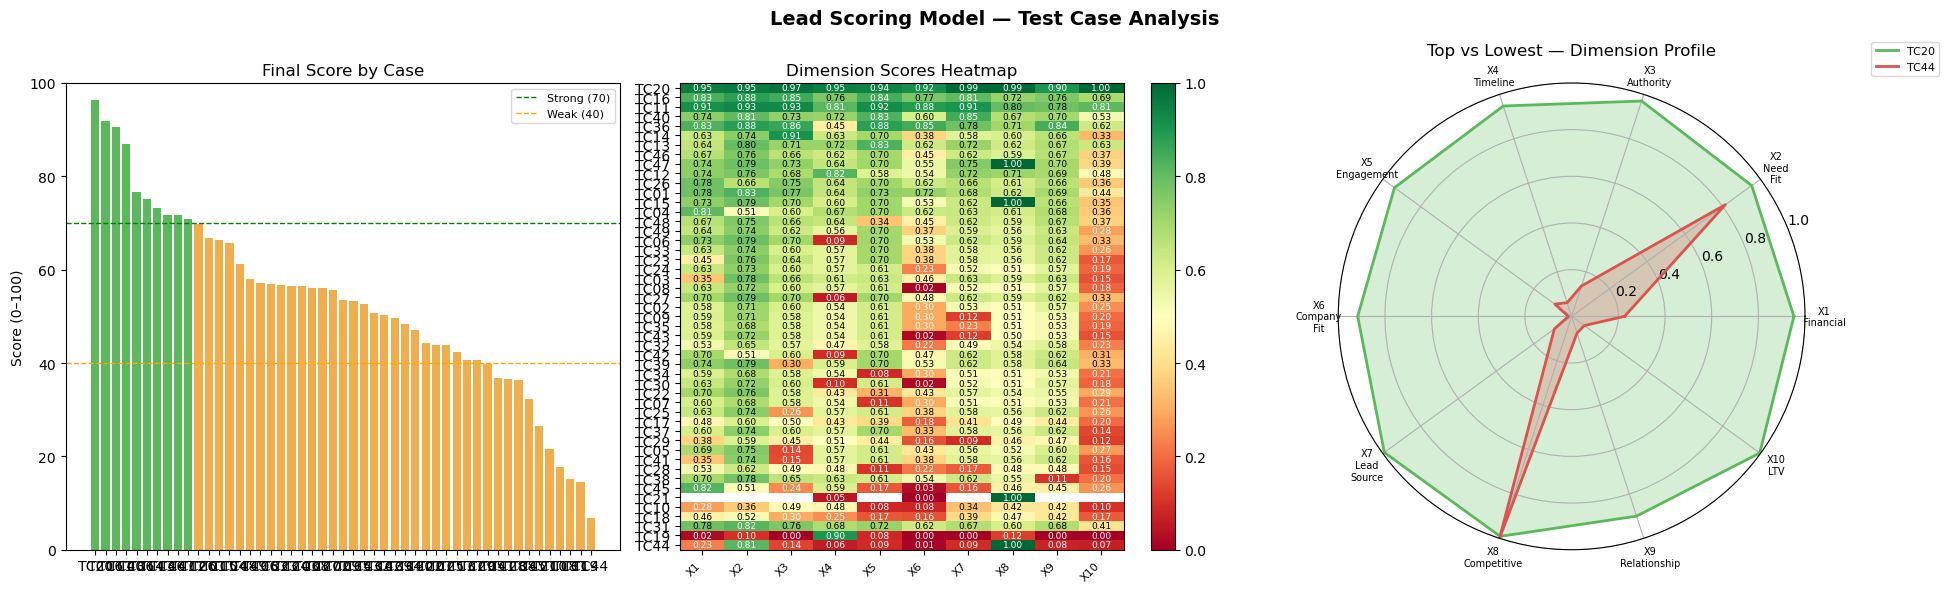

In [18]:
dim_cols = ["X1 Financial","X2 Need Fit","X3 Authority","X4 Timeline",
            "X5 Engagement","X6 Company Fit","X7 Lead Source",
            "X8 Competitive","X9 Relationship","X10 LTV"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Lead Scoring Model — Test Case Analysis", fontsize=14, fontweight="bold")

colors = ["#d9534f" if s == 0 else "#5cb85c" if s >= 70 else "#f0ad4e"
          for s in df_sorted["Score"]]
axes[0].bar(df_sorted["Case ID"], df_sorted["Score"], color=colors)
axes[0].set_title("Final Score by Case")
axes[0].set_ylabel("Score (0–100)")
axes[0].set_ylim(0, 100)
axes[0].axhline(70, color="green",  linestyle="--", linewidth=1, label="Strong (70)")
axes[0].axhline(40, color="orange", linestyle="--", linewidth=1, label="Weak (40)")
axes[0].legend(fontsize=8)

heat_data = df_sorted[dim_cols].values
im = axes[1].imshow(heat_data, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
axes[1].set_xticks(range(len(dim_cols)))
axes[1].set_xticklabels([c.split(" ")[0] for c in dim_cols], rotation=45, ha="right", fontsize=8)
axes[1].set_yticks(range(len(df_sorted)))
axes[1].set_yticklabels(df_sorted["Case ID"])
axes[1].set_title("Dimension Scores Heatmap")
plt.colorbar(im, ax=axes[1])

for i in range(len(df_sorted)):
    for j in range(len(dim_cols)):
        axes[1].text(j, i, f"{heat_data[i, j]:.2f}",
                     ha="center", va="center", fontsize=6.5,
                     color="black" if 0.3 < heat_data[i, j] < 0.8 else "white")

top_vals  = df_sorted.iloc[0][dim_cols].values.astype(float)
bot_vals  = df_sorted.iloc[-1][dim_cols].values.astype(float)
labels    = [c.replace(" ", "\n") for c in dim_cols]
N         = len(dim_cols)
angles    = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

top_vals  = np.append(top_vals, top_vals[0])
bot_vals  = np.append(bot_vals, bot_vals[0])
angles   += angles[:1]

ax3 = axes[2]
ax3.remove()
ax3 = fig.add_subplot(1, 3, 3, polar=True)
ax3.plot(angles, top_vals,  color="#5cb85c", linewidth=2, label=df_sorted.iloc[0]["Case ID"])
ax3.fill(angles, top_vals,  color="#5cb85c", alpha=0.25)
ax3.plot(angles, bot_vals,  color="#d9534f", linewidth=2, label=df_sorted.iloc[-1]["Case ID"])
ax3.fill(angles, bot_vals,  color="#d9534f", alpha=0.25)
ax3.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=7)
ax3.set_ylim(0, 1)
ax3.set_title("Top vs Lowest — Dimension Profile", pad=20)
ax3.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=8)

plt.tight_layout()
plt.show()


In [19]:
df_sorted.to_csv("lead_scores_results.csv", index=False)
print("Exported → lead_scores_results.csv")

Exported → lead_scores_results.csv
